# 2026 South African Local Government Election Analytics

## Problem Statement

The 2026 South African Local Government Election is scheduled for
4 November 2026. Municipal election outcomes are influenced by historical
voting patterns, voter participation, political party performance and
demographic and socio-economic conditions.

This project focuses on the eThekwini Metropolitan Municipality (ETH) in
KwaZulu-Natal. The aim is to develop a data science and machine learning
solution using credible, publicly available historical election and
supporting data available on or before 5 October 2026.

The project will analyse historical election patterns in eThekwini and
develop a model to estimate the outcome of the 4 November 2026 local
government election.

The analysis will:

- Collect and clean historical election data for eThekwini.
- Explore voter turnout and political party performance over time.
- Identify important patterns and factors associated with election results.
- Develop and evaluate appropriate predictive models.
- Produce a model-based estimate for the 4 November 2026 election.
- Report uncertainty, assumptions and limitations associated with the prediction.

The 2026 prediction will be presented as a model estimate and not as an
actual historical election result.

## Data Sources

All datasets used in this project are obtained from credible and traceable
public sources. Source links, dataset descriptions and access dates are
recorded to ensure reproducibility.

### Primary Election Data
- Source: Electoral Commission of South Africa (IEC)
- Municipality: eThekwini Metropolitan Municipality (ETH)
- Province: KwaZulu-Natal
- Dataset: Historical election results
- Source URL: [Insert the exact IEC download link here]
- Accessed: 5 October 2026

### Supporting Data
Additional demographic and socio-economic data will be obtained from
credible sources such as Statistics South Africa (Stats SA), where required.

## 4. Data Sources

The following credible and publicly available sources were used in this project:

### Election Data
- [Electoral Commission of South Africa (IEC) – Election Indicators Report](https://www.elections.org.za/content/Documents/Research-and-Statistics/Election-Indicators/IEC-Election-Indicators-National-Report-2021/)
  - Used for historical election and voter participation information.

### Demographic and Socioeconomic Data
- [Statistics South Africa – eThekwini Municipality](https://www.statssa.gov.za/?id=ethekwini-municipality&page_id=993)
  - Used for eThekwini demographic and socioeconomic indicators.

- [Statistics South Africa – KwaZulu-Natal Community Survey 2016](https://cs2016.statssa.gov.za/wp-content/uploads/2018/07/KZN.pdf)
  - Used for 2016 municipal demographic information.
  - [Stats SA – Quarterly Labour Force Survey, Q3 2021](https://www.statssa.gov.za/publications/P0211/P02113rdQuarter2021.pdf)
  - Used for the 2021 eThekwini unemployment rate

**Access date:** 5 October 2026

### Statistics South Africa

- [Stats SA – eThekwini Municipality](https://www.statssa.gov.za/?id=ethekwini-municipality&page_id=993)
  - Census 2011 population, unemployment and household statistics.

- [Stats SA – Community Survey 2016](https://cs2016.statssa.gov.za/)
  - Used for 2016 demographic information for eThekwini.

**Accessed:** 5 October 2026

 Data Loading and Initial Inspection

In [ ]:
import pandas as pd

election_files = {
    2011: "/content/2011.xls",
    2016: "/content/2016.xls",
    2021: "/content/2021.xls"
}

for year, file in election_files.items():

    print(f"\n{year} ELECTION")
    print("=" * 50)

    excel = pd.ExcelFile(file, engine="xlrd")

    print("Sheets:", excel.sheet_names)


2011 ELECTION
WARNING *** file size (21736) not 512 + multiple of sector size (512)
Sheets: ['Results Summary']

2016 ELECTION
WARNING *** file size (24448) not 512 + multiple of sector size (512)
Sheets: ['Results Summary']

2021 ELECTION
WARNING *** file size (32704) not 512 + multiple of sector size (512)
Sheets: ['Results Summary']


 Historical Data Inspection

In [ ]:
raw_elections = {}

for year, file in election_files.items():

    df_raw = pd.read_excel(
        file,
        sheet_name="Results Summary",
        header=None,
        engine="xlrd"
    )

    raw_elections[year] = df_raw

    print(f"\n{year} ELECTION")
    print("=" * 60)
    print("Shape:", df_raw.shape)

    display(df_raw.head(25))

WARNING *** file size (21736) not 512 + multiple of sector size (512)

2011 ELECTION
Shape: (40, 20)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Results Summary - All Ballots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2011/05/27 11:25:36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,NaN,NaN,NaN,NaN,Local Government Elections 2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,Province:,NaN,NaN,NaN,NaN,KwaZulu-Natal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,Municipality:,NaN,NaN,NaN,NaN,ETH - eThekwini [Durban Metro],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


WARNING *** file size (24448) not 512 + multiple of sector size (512)

2016 ELECTION
Shape: (50, 19)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Results Summary - All Ballots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2016/08/11 16:49:53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,NaN,NaN,NaN,LOCAL GOVERNMENT ELECTION 2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,Province:,NaN,NaN,NaN,KwaZulu-Natal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


WARNING *** file size (32704) not 512 + multiple of sector size (512)

2021 ELECTION
Shape: (76, 19)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Results Summary - All Ballots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2021/11/25 10:21:53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,NaN,NaN,NaN,LOCAL GOVERNMENT ELECTION 2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,Province:,NaN,NaN,NaN,KwaZulu-Natal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 Combining Historical Election Results

In [ ]:
def clean_election(df, year):

    # Different column positions in the IEC files
    if year == 2011:
        start_row = 17
        party_col = 1
        votes_col = 18
        share_col = 19
    else:
        start_row = 18
        party_col = 1
        votes_col = 17
        share_col = 18

    clean = df.iloc[start_row:, [party_col, votes_col, share_col]].copy()

    clean.columns = [
        "Party",
        "Total_Votes",
        "Vote_Share"
    ]

    # Remove rows without party names
    clean = clean.dropna(subset=["Party"])

    # Convert values to numeric
    clean["Total_Votes"] = pd.to_numeric(
        clean["Total_Votes"],
        errors="coerce"
    )

    clean["Vote_Share"] = pd.to_numeric(
        clean["Vote_Share"],
        errors="coerce"
    )

    # Remove summary rows
    summary_rows = [
        "Total Votes Cast",
        "Total Valid Votes",
        "Total Spoilt Votes"
    ]

    clean = clean[
        ~clean["Party"].astype(str).str.strip().isin(summary_rows)
    ]

    # Remove rows that aren't actual result observations
    clean = clean.dropna(subset=["Total_Votes", "Vote_Share"])

    clean["Year"] = year

    # Convert decimal share to percentage
    clean["Vote_Share_Pct"] = clean["Vote_Share"] * 100

    return clean

In [ ]:
election_2011 = clean_election(raw_elections[2011], 2011)
election_2016 = clean_election(raw_elections[2016], 2016)
election_2021 = clean_election(raw_elections[2021], 2021)

historical_results = pd.concat(
    [election_2011, election_2016, election_2021],
    ignore_index=True
)

display(historical_results.head(20))

,Party,Total_Votes,Vote_Share,Year,Vote_Share_Pct
0,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,2107.0,0.001085,2011,0.108481
1,AFRICAN CHRISTIAN DEMOCRATIC PARTY,14282.0,0.007353,2011,0.735321
2,AFRICAN NATIONAL CONGRESS,1186153.0,0.610701,2011,61.070103
3,AFRICAN PEOPLE'S CONVENTION,5884.0,0.003029,2011,0.302943
4,AZANIAN PEOPLE'S ORGANISATION,2638.0,0.001358,2011,0.135820
5,BLACK CONSCIOUSNESS PARTY,916.0,0.000472,2011,0.047161
6,CONGRESS OF THE PEOPLE,7310.0,0.003764,2011,0.376362
7,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,408179.0,0.210154,2011,21.015445
8,INDEPENDENT,17226.0,0.008869,2011,0.886895
9,INKATHA FREEDOM PARTY,80170.0,0.041276,2011,4.127621


Standardising Party Name

In [ ]:
# Remove unnecessary spaces
historical_results["Party"] = (
    historical_results["Party"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Standardise known naming differences
party_name_mapping = {
    "DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE":
        "DEMOCRATIC ALLIANCE"
}

historical_results["Party"] = (
    historical_results["Party"]
    .replace(party_name_mapping)
)

print("Party names standardised.")

Party names standardised.


In [ ]:
party_year_count = (
    historical_results
    .groupby("Party")["Year"]
    .nunique()
    .sort_values(ascending=False)
)

print("Number of election years each party appears in:")
display(party_year_count.head(20))

Number of election years each party appears in:


,Year
Party,
AFRICAN NATIONAL CONGRESS,3
TRULY ALLIANCE,3
AFRICAN CHRISTIAN DEMOCRATIC PARTY,3
AZANIAN PEOPLE'S ORGANISATION,3
AFRICAN PEOPLE'S CONVENTION,3
CONGRESS OF THE PEOPLE,3
DEMOCRATIC ALLIANCE,3
INKATHA FREEDOM PARTY,3
INDEPENDENT,3


In [ ]:
trend_table = historical_results.pivot_table(
    index="Party",
    columns="Year",
    values="Vote_Share_Pct",
    aggfunc="sum"
)

trend_table = trend_table.sort_values(
    2021,
    ascending=False
)

display(trend_table.head(15).round(2))

Year,2011,2016,2021
Party,,,
AFRICAN NATIONAL CONGRESS,61.07,56.01,42.14
DEMOCRATIC ALLIANCE,21.02,26.92,25.95
ECONOMIC FREEDOM FIGHTERS,NaN,3.44,10.48
INKATHA FREEDOM PARTY,4.13,4.20,7.06
INDEPENDENT,0.89,4.20,2.13
ACTIONSA,NaN,NaN,1.93
ACTIVE CITIZENS COALITION,NaN,NaN,0.92
AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.74,0.54,0.77
ABANTU BATHO CONGRESS,NaN,NaN,0.70


## Historical Election Trends

Vote-share trends across the 2011, 2016 and 2021 eThekwini Local Government Elections are compared to identify changes in party performance over time.

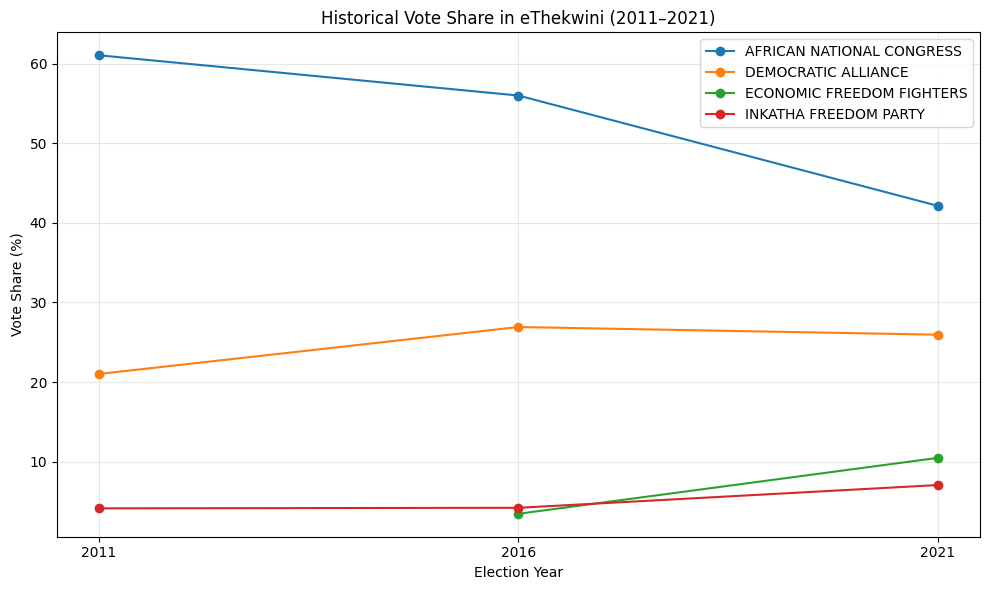

In [ ]:
import matplotlib.pyplot as plt

# Select parties with useful historical observations
trend_parties = [
    "AFRICAN NATIONAL CONGRESS",
    "DEMOCRATIC ALLIANCE",
    "ECONOMIC FREEDOM FIGHTERS",
    "INKATHA FREEDOM PARTY"
]

plt.figure(figsize=(10, 6))

for party in trend_parties:
    party_data = historical_results[
        historical_results["Party"] == party
    ].sort_values("Year")

    plt.plot(
        party_data["Year"],
        party_data["Vote_Share_Pct"],
        marker="o",
        label=party
    )

plt.xticks([2011, 2016, 2021])
plt.xlabel("Election Year")
plt.ylabel("Vote Share (%)")
plt.title("Historical Vote Share in eThekwini (2011–2021)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
major_trends = trend_table.loc[
    trend_table.index.intersection(trend_parties)
].copy()

major_trends["Change_2011_2016"] = (
    major_trends[2016] - major_trends[2011]
)

major_trends["Change_2016_2021"] = (
    major_trends[2021] - major_trends[2016]
)

display(major_trends.round(2))

Year,2011,2016,2021,Change_2011_2016,Change_2016_2021
Party,,,,,
AFRICAN NATIONAL CONGRESS,61.07,56.01,42.14,-5.06,-13.87
DEMOCRATIC ALLIANCE,21.02,26.92,25.95,5.90,-0.97
ECONOMIC FREEDOM FIGHTERS,NaN,3.44,10.48,NaN,7.03
INKATHA FREEDOM PARTY,4.13,4.20,7.06,0.07,2.86


## 16. Supporting Data

Additional electoral and socioeconomic variables are considered to provide context for historical voting patterns in eThekwini. Variables are obtained from credible sources such as the Electoral Commission of South Africa (IEC) and Statistics South Africa (Stats SA).

In [ ]:
supporting_data = pd.DataFrame({
    "Year": [2011, 2016, 2021],

    "Population": [
        3442361,   # Stats SA Census 2011
        3702231,   # Stats SA Community Survey 2016
        None       # No comparable 2021 census observation used
    ],

    "Unemployment_Rate": [
        30.2,      # Stats SA Census 2011
        None,      # Keep missing until comparable value is verified
        39.6       # Stats SA QLFS Q3 2021 - eThekwini
    ],

    "Households": [
        956713,    # Stats SA Census 2011
        None,
        None
    ]
})

display(supporting_data)

,Year,Population,Unemployment_Rate,Households
0,2011,3442361.0,30.2,956713.0
1,2016,3702231.0,NaN,NaN
2,2021,NaN,39.6,NaN


### 16.2 Election Participation Data

Election participation totals were extracted directly from the IEC Results Summary worksheets for eThekwini. The analysis uses the recorded valid votes, spoilt votes and total votes cast for each election year.

In [ ]:
election_summary = []

for year, df in raw_elections.items():

    # Find summary rows
    valid_row = df[df[1].astype(str).str.strip() == "Total Valid Votes"]
    spoilt_row = df[df[1].astype(str).str.strip() == "Total Spoilt Votes"]
    cast_row = df[df[1].astype(str).str.strip() == "Total Votes Cast"]

    # Total column differs for 2011
    total_col = 18 if year == 2011 else 17

    valid_votes = pd.to_numeric(
        valid_row.iloc[0, total_col], errors="coerce"
    )

    spoilt_votes = pd.to_numeric(
        spoilt_row.iloc[0, total_col], errors="coerce"
    )

    votes_cast = pd.to_numeric(
        cast_row.iloc[0, total_col], errors="coerce"
    )

    election_summary.append({
        "Year": year,
        "Valid_Votes": valid_votes,
        "Spoilt_Votes": spoilt_votes,
        "Votes_Cast": votes_cast
    })

election_summary = pd.DataFrame(election_summary)

display(election_summary)

,Year,Valid_Votes,Spoilt_Votes,Votes_Cast
0,2011,1942281,28619,1970900
1,2016,2225605,50276,2275881
2,2021,1550751,32590,1583341


In [ ]:
election_summary["Calculated_Votes_Cast"] = (
    election_summary["Valid_Votes"]
    + election_summary["Spoilt_Votes"]
)

election_summary["Difference"] = (
    election_summary["Votes_Cast"]
    - election_summary["Calculated_Votes_Cast"]
)

display(election_summary)

,Year,Valid_Votes,Spoilt_Votes,Votes_Cast,Calculated_Votes_Cast,Difference
0,2011,1942281,28619,1970900,1970900,0
1,2016,2225605,50276,2275881,2275881,0
2,2021,1550751,32590,1583341,1583341,0


### 16.3 Voter Participation

The IEC Results Summary provides a voter-turnout count for each election. This value is retained separately from total ballot votes because metropolitan voters cast both ward and proportional representation ballots.

In [ ]:
turnout_counts = {
    2011: 990263,
    2016: 1148559,
    2021: 803791
}

election_summary["Voter_Turnout_Count"] = (
    election_summary["Year"].map(turnout_counts)
)

display(election_summary)

,Year,Valid_Votes,Spoilt_Votes,Votes_Cast,Calculated_Votes_Cast,Difference,Voter_Turnout_Count
0,2011,1942281,28619,1970900,1970900,0,990263
1,2016,2225605,50276,2275881,2275881,0,1148559
2,2021,1550751,32590,1583341,1583341,0,803791


In [ ]:
election_summary["Turnout_Count_Change_Pct"] = (
    election_summary["Voter_Turnout_Count"]
    .pct_change() * 100
)

display(election_summary.round(2))

,Year,Valid_Votes,Spoilt_Votes,Votes_Cast,Calculated_Votes_Cast,Difference,Voter_Turnout_Count,Turnout_Count_Change_Pct
0,2011,1942281,28619,1970900,1970900,0,990263,NaN
1,2016,2225605,50276,2275881,2275881,0,1148559,15.99
2,2021,1550751,32590,1583341,1583341,0,803791,-30.02


## 17. Socioeconomic Supporting Data

Socioeconomic data for eThekwini are incorporated to provide demographic context for the historical election analysis. Only publicly available and traceable statistics are used, and estimated values are not presented as historical observations.

In [ ]:
supporting_data = pd.DataFrame({
    "Year": [2011, 2016, 2021],

    "Population": [
        3442361,   # Stats SA Census 2011
        3702231,   # Stats SA Community Survey 2016
        None       # Not inserted until verified
    ],

    "Unemployment_Rate": [
        30.2,      # Stats SA Census 2011
        None,      # Not inserted until verified
        None       # Not inserted until verified
    ],

    "Households": [
        956713,    # Stats SA Census 2011
        None,
        None
    ]
})

display(supporting_data)

,Year,Population,Unemployment_Rate,Households
0,2011,3442361.0,30.2,956713.0
1,2016,3702231.0,NaN,NaN
2,2021,NaN,NaN,NaN


### Data Quality Note

Missing socioeconomic values are retained as `NaN` until a credible and traceable source is identified. No missing historical observations are fabricated or presented as observed data.

In [ ]:
print("Supporting Dataset")
print("=" * 50)

display(supporting_data)

print("\nMissing values:")
print(supporting_data.isnull().sum())

print("\nData types:")
print(supporting_data.dtypes)

Supporting Dataset


,Year,Population,Unemployment_Rate,Households
0,2011,3442361.0,30.2,956713.0
1,2016,3702231.0,NaN,NaN
2,2021,NaN,39.6,NaN



Missing values:
Year                 0
Population           1
Unemployment_Rate    1
Households           2
dtype: int64

Data types:
Year                   int64
Population           float64
Unemployment_Rate    float64
Households           float64
dtype: object


## 18. Granular Election Data

Municipality-level election results provide only three historical election periods. To increase the number of observations available for modelling, more detailed IEC election results at ward or voting-district level are investigated.

The Electoral Commission of South Africa provides official Local Government Election results at municipality, ward and voting-district levels.

In [ ]:
import pandas as pd

file = "/content/ETH.xls"

excel = pd.ExcelFile(file, engine="xlrd")

print("File:", file)
print("Sheets:", excel.sheet_names)

for sheet in excel.sheet_names:
    df_check = pd.read_excel(
        file,
        sheet_name=sheet,
        header=None,
        engine="xlrd"
    )

    print("\nSheet:", sheet)
    print("Shape:", df_check.shape)

    display(df_check.head(20))

WARNING *** file size (32704) not 512 + multiple of sector size (512)
File: /content/ETH.xls
Sheets: ['Results Summary']
WARNING *** file size (32704) not 512 + multiple of sector size (512)

Sheet: Results Summary
Shape: (76, 19)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Results Summary - All Ballots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2021/11/25 10:21:53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,NaN,NaN,NaN,LOCAL GOVERNMENT ELECTION 2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,Province:,NaN,NaN,NaN,KwaZulu-Natal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 19. Loading Detailed Election Results

Detailed IEC Local Government Election results for eThekwini are used to increase the granularity of the analysis. The datasets contain results at voting-district level for the 2011, 2016 and 2021 elections.

For consistency across election years, the analysis focuses on Proportional Representation (PR) ballots.

In [ ]:
import pandas as pd

def load_iec_csv(filepath):
    encodings = ["utf-16", "utf-8-sig", "utf-8", "latin1"]

    for encoding in encodings:
        try:
            df = pd.read_csv(filepath, encoding=encoding)
            print(f"Loaded {filepath} using {encoding}")
            return df
        except (UnicodeDecodeError, UnicodeError):
            continue

    raise ValueError(f"Could not determine encoding for {filepath}")


election_2011_detail = load_iec_csv(
    "/content/2011_eThekwini_PR_Detailed.csv"
)

election_2016_detail = load_iec_csv(
    "/content/2016_eThekwini_Detailed.csv"
)

election_2021_detail = load_iec_csv(
    "/content/2021_eThekwini_PR_Detailed.csv"
)

print("\nDataset shapes:")
print("2011:", election_2011_detail.shape)
print("2016:", election_2016_detail.shape)
print("2021:", election_2021_detail.shape)

Loaded /content/2011_eThekwini_PR_Detailed.csv using utf-16
Loaded /content/2016_eThekwini_Detailed.csv using utf-8-sig
Loaded /content/2021_eThekwini_PR_Detailed.csv using utf-8-sig

Dataset shapes:
2011: (13617, 11)
2016: (40706, 11)
2021: (43750, 11)


In [ ]:
# Inspect structure of all three election datasets

for year, df in [
    (2011, election_2011_detail),
    (2016, election_2016_detail),
    (2021, election_2021_detail)
]:
    print("\n" + "=" * 70)
    print(f"{year} ELECTION DATA")
    print("=" * 70)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nFirst 5 rows:")
    display(df.head())

    print("\nData types:")
    print(df.dtypes)

    print("\nMissing values:")
    print(df.isnull().sum())


2011 ELECTION DATA

Columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

First 5 rows:


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1,5/26/2011 4:40:02 PM
1,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,5/26/2011 4:40:02 PM
2,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN NATIONAL CONGRESS,973,5/26/2011 4:40:02 PM
3,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN PEOPLE'S CONVENTION,2,5/26/2011 4:40:02 PM
4,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AZANIAN PEOPLE'S ORGANISATION,1,5/26/2011 4:40:02 PM



Data types:
Province             object
Municipality         object
Ward                 object
VotingDistrict        int64
VotingStationName    object
RegisteredVoters      int64
BallotType           object
SpoiltVotes           int64
PartyName            object
TotalValidVotes       int64
DateGenerated        object
dtype: object

Missing values:
Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
dtype: int64

2016 ELECTION DATA

Columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

First 5 rows:


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,ACADEMIC CONGRESS UNION,0,8/11/2016 12:54:25 PM
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,8/11/2016 12:54:25 PM
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN INDEPENDENT CONGRESS,19,8/11/2016 12:54:25 PM
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN MANTUNGWA COMMUNITY,0,8/11/2016 12:54:25 PM
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1607,PR,72,AFRICAN NATIONAL CONGRESS,1157,8/11/2016 12:54:25 PM



Data types:
Province             object
Municipality         object
Ward                 object
VotingDistrict        int64
VotingStationName    object
RegisteredVoters      int64
BallotType           object
SpoiltVotes           int64
PartyName            object
TotalValidVotes       int64
DateGenerated        object
dtype: object

Missing values:
Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
dtype: int64

2021 ELECTION DATA

Columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

First 5 rows:


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated
0,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ABANTU BATHO CONGRESS,14,11/23/2021 4:23:24 PM
1,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACADEMIC CONGRESS UNION,0,11/23/2021 4:23:24 PM
2,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACTIONSA,0,11/23/2021 4:23:24 PM
3,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACTIVE CITIZENS COALITION,0,11/23/2021 4:23:24 PM
4,KwaZulu-Natal,ETH - eThekwini,Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,2365,PR,12,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0,11/23/2021 4:23:24 PM



Data types:
Province             object
Municipality         object
Ward                 object
VotingDistrict        int64
VotingStationName    object
RegisteredVoters      int64
BallotType           object
SpoiltVotes           int64
PartyName            object
TotalValidVotes       int64
DateGenerated        object
dtype: object

Missing values:
Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
dtype: int64


## Historical Election Data Inspection

Historical eThekwini local government election results from 2011, 2016
and 2021 are inspected before preprocessing.

The purpose of this step is to verify that the datasets have compatible
structures, identify the variables required for modelling, inspect ballot
types, and detect missing values before the election datasets are combined.

Particular attention is given to party votes, registered voters, wards,
voting districts and ballot types because these variables will be used to
analyse historical voting patterns and construct features for the 2026
election prediction model.

In [ ]:
# PRIORITY CHECK: Compare column structures

print("2011 columns:")
print(election_2011_detail.columns.tolist())

print("\n2016 columns:")
print(election_2016_detail.columns.tolist())

print("\n2021 columns:")
print(election_2021_detail.columns.tolist())

print("\nNumber of columns:")
print("2011:", election_2011_detail.shape[1])
print("2016:", election_2016_detail.shape[1])
print("2021:", election_2021_detail.shape[1])

2011 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

2016 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

2021 columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']

Number of columns:
2011: 11
2016: 11
2021: 11


In [ ]:

for year, df in [
    (2011, election_2011_detail),
    (2016, election_2016_detail),
    (2021, election_2021_detail)
]:
    print(f"\n{year} Ballot Types:")
    print(df["BallotType"].value_counts())


2011 Ballot Types:
BallotType
PR    13617
Name: count, dtype: int64

2016 Ballot Types:
BallotType
PR      23382
Ward    17324
Name: count, dtype: int64

2021 Ballot Types:
BallotType
PR    43750
Name: count, dtype: int64


## Data Standardisation: Selection of PR Ballots

Before combining the historical election datasets, the ballot types were
examined to ensure that the election years are comparable.

The 2011 and 2021 datasets contain only Proportional Representation (PR)
ballots, while the 2016 dataset contains both PR and Ward ballots.

To maintain consistency across the three election years, only PR ballot
records are retained. This prevents the 2016 results from including an
additional ballot type that is not present in the 2011 and 2021 datasets.

An `ElectionYear` variable is also added to each dataset so that observations
can be identified by election year after the datasets are combined.

In [ ]:
# Keep only PR ballots for consistent comparison

election_2011_pr = election_2011_detail[
    election_2011_detail["BallotType"] == "PR"
].copy()

election_2016_pr = election_2016_detail[
    election_2016_detail["BallotType"] == "PR"
].copy()

election_2021_pr = election_2021_detail[
    election_2021_detail["BallotType"] == "PR"
].copy()

# Add the election year
election_2011_pr["ElectionYear"] = 2011
election_2016_pr["ElectionYear"] = 2016
election_2021_pr["ElectionYear"] = 2021

# Check the resulting datasets
print("PR dataset shapes:")
print("2011:", election_2011_pr.shape)
print("2016:", election_2016_pr.shape)
print("2021:", election_2021_pr.shape)

PR dataset shapes:
2011: (13617, 12)
2016: (23382, 12)
2021: (43750, 12)


## Combining Historical Election Data

After standardising the ballot type, the 2011, 2016 and 2021 eThekwini
PR election datasets are combined into a single historical dataset.

Combining the datasets allows voting patterns to be analysed across multiple
local government elections while the `ElectionYear` variable preserves the
time dimension of the data.

The combined dataset will form the main historical election dataset used
for exploratory analysis and the development of the 2026 election
prediction model.

In [ ]:
# Combine the three historical PR election datasets

election_data = pd.concat(
    [
        election_2011_pr,
        election_2016_pr,
        election_2021_pr
    ],
    ignore_index=True
)

print("Combined dataset shape:")
print(election_data.shape)

print("\nRecords by election year:")
print(
    election_data["ElectionYear"]
    .value_counts()
    .sort_index()
)

print("\nBallot types in combined dataset:")
print(election_data["BallotType"].value_counts())

display(election_data.head())

Combined dataset shape:
(80749, 12)

Records by election year:
ElectionYear
2011    13617
2016    23382
2021    43750
Name: count, dtype: int64

Ballot types in combined dataset:
BallotType
PR    80749
Name: count, dtype: int64


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated,ElectionYear
0,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1,5/26/2011 4:40:02 PM,2011
1,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,5/26/2011 4:40:02 PM,2011
2,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN NATIONAL CONGRESS,973,5/26/2011 4:40:02 PM,2011
3,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN PEOPLE'S CONVENTION,2,5/26/2011 4:40:02 PM,2011
4,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AZANIAN PEOPLE'S ORGANISATION,1,5/26/2011 4:40:02 PM,2011


## Initial Data Quality Assessment

Before conducting exploratory analysis or developing a machine learning
model, the combined historical election dataset is checked for potential
data-quality problems.

The assessment examines:

- Missing values
- Duplicate records
- Election year coverage
- Number of political parties
- Invalid or negative vote values
- Invalid registered-voter values

These checks are important because errors in historical election data could
affect calculated party support, trends and the final 2026 election
prediction.

In [ ]:
print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

# Missing values
print("\n1. Missing values:")
print(election_data.isnull().sum())

# Duplicate rows
print("\n2. Number of duplicate rows:")
print(election_data.duplicated().sum())

# Election years
print("\n3. Election years:")
print(sorted(election_data["ElectionYear"].unique()))

# Number of unique parties
print("\n4. Unique political parties:")
print(election_data["PartyName"].nunique())

# Check negative votes
print("\n5. Records with negative TotalValidVotes:")
print((election_data["TotalValidVotes"] < 0).sum())

# Check negative registered voters
print("\n6. Records with negative RegisteredVoters:")
print((election_data["RegisteredVoters"] < 0).sum())

# Basic statistics
print("\n7. Vote statistics:")
display(
    election_data[
        ["RegisteredVoters", "SpoiltVotes", "TotalValidVotes"]
    ].describe()
)

DATA QUALITY CHECK

1. Missing values:
Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
ElectionYear         0
dtype: int64

2. Number of duplicate rows:
0

3. Election years:
[np.int64(2011), np.int64(2016), np.int64(2021)]

4. Unique political parties:
62

5. Records with negative TotalValidVotes:
0

6. Records with negative RegisteredVoters:
0

7. Vote statistics:


,RegisteredVoters,SpoiltVotes,TotalValidVotes
count,80749.000000,80749.000000,80749.000000
mean,2174.889237,23.931491,35.331905
std,1190.265844,38.982448,176.930158
min,101.000000,0.000000,0.000000
25%,1333.000000,6.000000,0.000000
50%,2054.000000,15.000000,1.000000
75%,2810.000000,29.000000,3.000000
max,8099.000000,993.000000,4064.000000


## Geographic Consistency Check

The analysis focuses specifically on the eThekwini Metropolitan Municipality
in KwaZulu-Natal. Before aggregating election results, the geographic fields
are checked to confirm that the historical dataset contains only observations
belonging to the intended municipality and province.

This validation reduces the risk of accidentally including election results
from another municipality or province in the 2026 eThekwini election model.

In [ ]:
# Check geographic consistency

print("Unique provinces:")
print(election_data["Province"].value_counts())

print("\nUnique municipalities:")
print(election_data["Municipality"].value_counts())

print("\nNumber of unique wards by election year:")
print(
    election_data.groupby("ElectionYear")["Ward"]
    .nunique()
)

print("\nNumber of unique voting districts by election year:")
print(
    election_data.groupby("ElectionYear")["VotingDistrict"]
    .nunique()
)

Unique provinces:
Province
KwaZulu-Natal    80749
Name: count, dtype: int64

Unique municipalities:
Municipality
ETH - eThekwini                   67132
ETH - eThekwini [Durban Metro]    13617
Name: count, dtype: int64

Number of unique wards by election year:
ElectionYear
2011    103
2016    110
2021    111
Name: Ward, dtype: int64

Number of unique voting districts by election year:
ElectionYear
2011    801
2016    866
2021    875
Name: VotingDistrict, dtype: int64


In [ ]:
# Standardise the eThekwini municipality name

election_data["Municipality"] = election_data["Municipality"].replace(
    {
        "ETH - eThekwini [Durban Metro]": "ETH - eThekwini"
    }
)

# Verify the result
print("Municipality names after standardisation:")
print(election_data["Municipality"].value_counts())

print("\nProvince:")
print(election_data["Province"].value_counts())

Municipality names after standardisation:
Municipality
ETH - eThekwini    80749
Name: count, dtype: int64

Province:
Province
KwaZulu-Natal    80749
Name: count, dtype: int64


## Changes in Electoral Geography

The number of wards and voting districts in eThekwini differs between the
three historical elections.

- 2011 contained 103 wards and 801 voting districts.
- 2016 contained 110 wards and 866 voting districts.
- 2021 contained 111 wards and 875 voting districts.

This indicates that the electoral geography is not completely stable across
the historical period. Ward boundaries and voting-district structures may
change between elections.

For this reason, municipality-level party vote share will be used as the
primary measure for analysing long-term party trends. Ward and voting-district
information will still be retained for exploratory geographic analysis, but
ward identifiers will not automatically be treated as identical geographic
units across all election years.

In [ ]:
# Create a summary of electoral geography by election year

geography_summary = (
    election_data
    .groupby("ElectionYear")
    .agg(
        NumberOfWards=("Ward", "nunique"),
        NumberOfVotingDistricts=("VotingDistrict", "nunique")
    )
    .reset_index()
)

display(geography_summary)

,ElectionYear,NumberOfWards,NumberOfVotingDistricts
0,2011,103,801
1,2016,110,866
2,2021,111,875


In [ ]:
# Count unique political parties by election year

party_counts = (
    election_data
    .groupby("ElectionYear")["PartyName"]
    .nunique()
    .reset_index(name="NumberOfParties")
)

display(party_counts)

# Show party names for each election
for year in sorted(election_data["ElectionYear"].unique()):

    parties = sorted(
        election_data.loc[
            election_data["ElectionYear"] == year,
            "PartyName"
        ].unique()
    )

    print("\n" + "=" * 60)
    print(f"{year} POLITICAL PARTIES ({len(parties)})")
    print("=" * 60)

    for party in parties:
        print(party)

,ElectionYear,NumberOfParties
0,2011,17
1,2016,27
2,2021,50



2011 POLITICAL PARTIES (17)
AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ALLIANSIE
AFRICAN CHRISTIAN DEMOCRATIC PARTY
AFRICAN NATIONAL CONGRESS
AFRICAN PEOPLE'S CONVENTION
AZANIAN PEOPLE'S ORGANISATION
BLACK CONSCIOUSNESS PARTY
CONGRESS  OF THE PEOPLE
DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE
INKATHA FREEDOM PARTY
MINORITY FRONT
NATIONAL FREEDOM PARTY
SOCIALIST GREEN COALITION
SOLIDARITY PARTY
TRULY ALLIANCE
UNITED ACTION FRONT
UNITED DEMOCRATIC MOVEMENT
VRYHEIDSFRONT PLUS

2016 POLITICAL PARTIES (27)
ACADEMIC CONGRESS UNION
AFRICAN CHRISTIAN DEMOCRATIC PARTY
AFRICAN INDEPENDENT CONGRESS
AFRICAN MANTUNGWA COMMUNITY
AFRICAN NATIONAL CONGRESS
AFRICAN PEOPLE'S CONVENTION
AL JAMA-AH
ALLIED MOVEMENT FOR CHANGE
AZANIAN PEOPLE'S ORGANISATION
CONGRESS  OF THE PEOPLE
DEMOCRATIC ALLIANCE
DEMOCRATIC LIBERAL CONGRESS
ECONOMIC FREEDOM FIGHTERS
INDEPENDENT PEOPLE'S PARTY
INDEPENDENT RATEPAYERS ASSOCIATION OF SA
INKATHA FREEDOM PARTY
MINORITIES OF SOUTH AFRICA
MINORITY FRONT
PAN AFRICANIST CONGRES

## Calculation of Historical Party Vote Share

The raw election data contains one observation for each political party at a
particular voting district. These records are aggregated to municipality level
to measure the overall performance of each party in eThekwini.

For each election year, the total number of valid PR votes received by each
party is calculated.

The total valid PR vote for the election is then calculated and used to
determine each party's percentage vote share.

The vote share is calculated as:

**Vote Share (%) = (Party Votes / Total Valid PR Votes) × 100**

Percentage vote share provides a more comparable measure of political support
than raw vote totals because the number of registered voters, voting districts
and participating voters can change between elections.

In [ ]:
# Aggregate total PR votes for each party and election year

party_results = (
    election_data
    .groupby(
        ["ElectionYear", "PartyName"],
        as_index=False
    )["TotalValidVotes"]
    .sum()
)

# Rename the aggregated vote column
party_results = party_results.rename(
    columns={
        "TotalValidVotes": "PartyVotes"
    }
)

# Calculate total valid PR votes for each election
party_results["ElectionTotalVotes"] = (
    party_results
    .groupby("ElectionYear")["PartyVotes"]
    .transform("sum")
)

# Calculate percentage vote share
party_results["VoteShare"] = (
    party_results["PartyVotes"]
    / party_results["ElectionTotalVotes"]
) * 100

# Sort parties from highest to lowest within each election
party_results = party_results.sort_values(
    ["ElectionYear", "VoteShare"],
    ascending=[True, False]
).reset_index(drop=True)

display(party_results.head(20))

,ElectionYear,PartyName,PartyVotes,ElectionTotalVotes,VoteShare
0,2011,AFRICAN NATIONAL CONGRESS,603929,973728,62.022351
1,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,212409,973728,21.813997
2,2011,MINORITY FRONT,48064,973728,4.936081
3,2011,NATIONAL FREEDOM PARTY,43606,973728,4.478253
4,2011,INKATHA FREEDOM PARTY,38532,973728,3.957163
5,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6555,973728,0.673186
6,2011,TRULY ALLIANCE,6026,973728,0.618859
7,2011,AFRICAN PEOPLE'S CONVENTION,3970,973728,0.407711
8,2011,CONGRESS OF THE PEOPLE,3882,973728,0.398674
9,2011,UNITED ACTION FRONT,1256,973728,0.128989


In [ ]:
# Display top 10 parties for every election year

for year in sorted(party_results["ElectionYear"].unique()):

    top_10 = (
        party_results[
            party_results["ElectionYear"] == year
        ]
        .nlargest(10, "VoteShare")
        [
            ["PartyName", "PartyVotes", "VoteShare"]
        ]
    )

    print("\n" + "=" * 70)
    print(f"TOP 10 PARTIES IN eTHEKWINI - {year}")
    print("=" * 70)

    display(
        top_10.style.format(
            {
                "PartyVotes": "{:,.0f}",
                "VoteShare": "{:.2f}%"
            }
        )
    )


TOP 10 PARTIES IN eTHEKWINI - 2011


,PartyName,PartyVotes,VoteShare
0,AFRICAN NATIONAL CONGRESS,"603,929",62.02%
1,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,"212,409",21.81%
2,MINORITY FRONT,"48,064",4.94%
3,NATIONAL FREEDOM PARTY,"43,606",4.48%
4,INKATHA FREEDOM PARTY,"38,532",3.96%
5,AFRICAN CHRISTIAN DEMOCRATIC PARTY,"6,555",0.67%
6,TRULY ALLIANCE,"6,026",0.62%
7,AFRICAN PEOPLE'S CONVENTION,"3,970",0.41%
8,CONGRESS OF THE PEOPLE,"3,882",0.40%
9,UNITED ACTION FRONT,"1,256",0.13%



TOP 10 PARTIES IN eTHEKWINI - 2016


,PartyName,PartyVotes,VoteShare
17,AFRICAN NATIONAL CONGRESS,"652,891",59.11%
18,DEMOCRATIC ALLIANCE,"304,206",27.54%
19,INKATHA FREEDOM PARTY,"47,260",4.28%
20,ECONOMIC FREEDOM FIGHTERS,"40,087",3.63%
21,AFRICAN INDEPENDENT CONGRESS,"16,673",1.51%
22,AFRICAN CHRISTIAN DEMOCRATIC PARTY,"5,956",0.54%
23,MINORITY FRONT,"5,070",0.46%
24,DEMOCRATIC LIBERAL CONGRESS,"4,801",0.43%
25,TRULY ALLIANCE,"4,686",0.42%
26,MINORITIES OF SOUTH AFRICA,"3,018",0.27%



TOP 10 PARTIES IN eTHEKWINI - 2021


,PartyName,PartyVotes,VoteShare
44,AFRICAN NATIONAL CONGRESS,"329,307",42.51%
45,DEMOCRATIC ALLIANCE,"203,980",26.33%
46,ECONOMIC FREEDOM FIGHTERS,"83,699",10.80%
47,INKATHA FREEDOM PARTY,"57,722",7.45%
48,ACTIONSA,"18,201",2.35%
49,AFRICAN INDEPENDENT CONGRESS,"7,809",1.01%
50,ACTIVE CITIZENS COALITION,"6,239",0.81%
51,AFRICAN CHRISTIAN DEMOCRATIC PARTY,"5,893",0.76%
52,ABANTU BATHO CONGRESS,"4,998",0.65%
53,JUSTICE AND EMPLOYMENT PARTY,"4,763",0.61%


## Standardisation of Political Party Names

Inspection of the historical election results identified differences in the
way some political party names are recorded across election years.

For example, the Democratic Alliance is recorded as
`DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE` in the 2011 dataset but as
`DEMOCRATIC ALLIANCE` in later elections.

If these labels are not standardised, the same political party would be
incorrectly treated as different parties during longitudinal analysis.

Known naming inconsistencies are therefore standardised before historical
party trends are constructed.

In [ ]:
# Standardise known political party name differences

party_name_mapping = {
    "DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE":
        "DEMOCRATIC ALLIANCE"
}

election_data["PartyName"] = (
    election_data["PartyName"]
    .replace(party_name_mapping)
)

# Verify DA naming
print(
    election_data[
        election_data["PartyName"].str.contains(
            "DEMOCRATIC ALLIANCE",
            case=False,
            na=False
        )
    ]["PartyName"].value_counts()
)

PartyName
DEMOCRATIC ALLIANCE    2542
Name: count, dtype: int64


## Recalculation of Standardised Party Results

Following the standardisation of political party names, party-level election
results are recalculated.

This ensures that observations belonging to the same political organisation
are consistently represented across election years before historical trends
are analysed.

In [ ]:
# Recalculate party-level results after name standardisation

party_results = (
    election_data
    .groupby(
        ["ElectionYear", "PartyName"],
        as_index=False
    )["TotalValidVotes"]
    .sum()
    .rename(
        columns={"TotalValidVotes": "PartyVotes"}
    )
)

# Election total
party_results["ElectionTotalVotes"] = (
    party_results
    .groupby("ElectionYear")["PartyVotes"]
    .transform("sum")
)

# Vote share
party_results["VoteShare"] = (
    party_results["PartyVotes"]
    / party_results["ElectionTotalVotes"]
) * 100

party_results = party_results.sort_values(
    ["ElectionYear", "VoteShare"],
    ascending=[True, False]
).reset_index(drop=True)

display(party_results.head())

,ElectionYear,PartyName,PartyVotes,ElectionTotalVotes,VoteShare
0,2011,AFRICAN NATIONAL CONGRESS,603929,973728,62.022351
1,2011,DEMOCRATIC ALLIANCE,212409,973728,21.813997
2,2011,MINORITY FRONT,48064,973728,4.936081
3,2011,NATIONAL FREEDOM PARTY,43606,973728,4.478253
4,2011,INKATHA FREEDOM PARTY,38532,973728,3.957163


## Historical Continuity of Political Parties

Not every political party contested all three historical elections.

A party with observations in 2011, 2016 and 2021 provides a longer historical
series than a party that entered the electoral contest more recently.

The number of election years represented for each party is therefore
calculated. This information will later be used when selecting appropriate
forecasting approaches and when interpreting prediction uncertainty.

Importantly, the absence of a party from an election is not automatically
treated as a zero vote share because the party may not have contested that
election.

In [ ]:
# Determine the number of historical elections represented by each party

party_continuity = (
    party_results
    .groupby("PartyName")
    .agg(
        ElectionsContested=("ElectionYear", "nunique"),
        FirstObservedElection=("ElectionYear", "min"),
        LastObservedElection=("ElectionYear", "max")
    )
    .reset_index()
    .sort_values(
        ["ElectionsContested", "PartyName"],
        ascending=[False, True]
    )
)

display(party_continuity)

,PartyName,ElectionsContested,FirstObservedElection,LastObservedElection
9,AFRICAN CHRISTIAN DEMOCRATIC PARTY,3,2011,2021
15,AFRICAN NATIONAL CONGRESS,3,2011,2021
17,AFRICAN PEOPLE'S CONVENTION,3,2011,2021
22,AZANIAN PEOPLE'S ORGANISATION,3,2011,2021
25,CONGRESS OF THE PEOPLE,3,2011,2021
...,...,...,...,...
54,UNITED CHRISTIAN DEMOCRATIC PARTY,1,2021,2021
55,UNITED CULTURAL MOVEMENT,1,2021,2021
57,UNITED INDEPENDENT MOVEMENT,1,2021,2021
58,UNITED PEOPLES PARTY,1,2016,2016


## Historical Performance of Major Political Parties

The historical performance of major political parties is examined to identify
changes in electoral support over time.

Particular attention is given to the African National Congress (ANC),
Democratic Alliance (DA), Inkatha Freedom Party (IFP), Economic Freedom
Fighters (EFF), and ActionSA because these parties represent important shares
of the most recent eThekwini PR vote.

The analysis distinguishes between parties with a complete three-election
history and newer parties with shorter historical records. This distinction
will be important when developing the 2026 prediction because predictions for
newer parties carry greater uncertainty.

In [ ]:
# Major parties selected from recent and historical election results

major_parties = [
    "AFRICAN NATIONAL CONGRESS",
    "DEMOCRATIC ALLIANCE",
    "INKATHA FREEDOM PARTY",
    "ECONOMIC FREEDOM FIGHTERS",
    "ACTIONSA"
]

major_party_results = (
    party_results[
        party_results["PartyName"].isin(major_parties)
    ]
    .copy()
)

# Create historical vote-share table
major_party_table = (
    major_party_results
    .pivot(
        index="PartyName",
        columns="ElectionYear",
        values="VoteShare"
    )
)

display(
    major_party_table.style.format(
        "{:.2f}%"
    )
)

ElectionYear,2011,2016,2021
PartyName,,,
ACTIONSA,nan%,nan%,2.35%
AFRICAN NATIONAL CONGRESS,62.02%,59.11%,42.51%
DEMOCRATIC ALLIANCE,21.81%,27.54%,26.33%
ECONOMIC FREEDOM FIGHTERS,nan%,3.63%,10.80%
INKATHA FREEDOM PARTY,3.96%,4.28%,7.45%


In [ ]:
# Sort observations chronologically
major_party_results = major_party_results.sort_values(
    ["PartyName", "ElectionYear"]
)

# Calculate change in percentage points from previous observed election
major_party_results["VoteShareChange"] = (
    major_party_results
    .groupby("PartyName")["VoteShare"]
    .diff()
)

display(
    major_party_results[
        [
            "ElectionYear",
            "PartyName",
            "PartyVotes",
            "VoteShare",
            "VoteShareChange"
        ]
    ].style.format(
        {
            "PartyVotes": "{:,.0f}",
            "VoteShare": "{:.2f}%",
            "VoteShareChange": "{:+.2f} pp"
        },
        na_rep="N/A"
    )
)

,ElectionYear,PartyName,PartyVotes,VoteShare,VoteShareChange
48,2021,ACTIONSA,"18,201",2.35%,N/A
0,2011,AFRICAN NATIONAL CONGRESS,"603,929",62.02%,N/A
17,2016,AFRICAN NATIONAL CONGRESS,"652,891",59.11%,-2.91 pp
44,2021,AFRICAN NATIONAL CONGRESS,"329,307",42.51%,-16.60 pp
1,2011,DEMOCRATIC ALLIANCE,"212,409",21.81%,N/A
18,2016,DEMOCRATIC ALLIANCE,"304,206",27.54%,+5.73 pp
45,2021,DEMOCRATIC ALLIANCE,"203,980",26.33%,-1.21 pp
20,2016,ECONOMIC FREEDOM FIGHTERS,"40,087",3.63%,N/A
46,2021,ECONOMIC FREEDOM FIGHTERS,"83,699",10.80%,+7.17 pp
4,2011,INKATHA FREEDOM PARTY,"38,532",3.96%,N/A


## Historical Vote Share Trends

A line chart is used to visualise changes in the PR vote share of the major
political parties across the available local government elections.

The chart should be interpreted as a description of historical election
results rather than as a prediction of the 2026 election.

Missing observations for parties that did not contest earlier elections are
left missing rather than artificially replaced with zero.

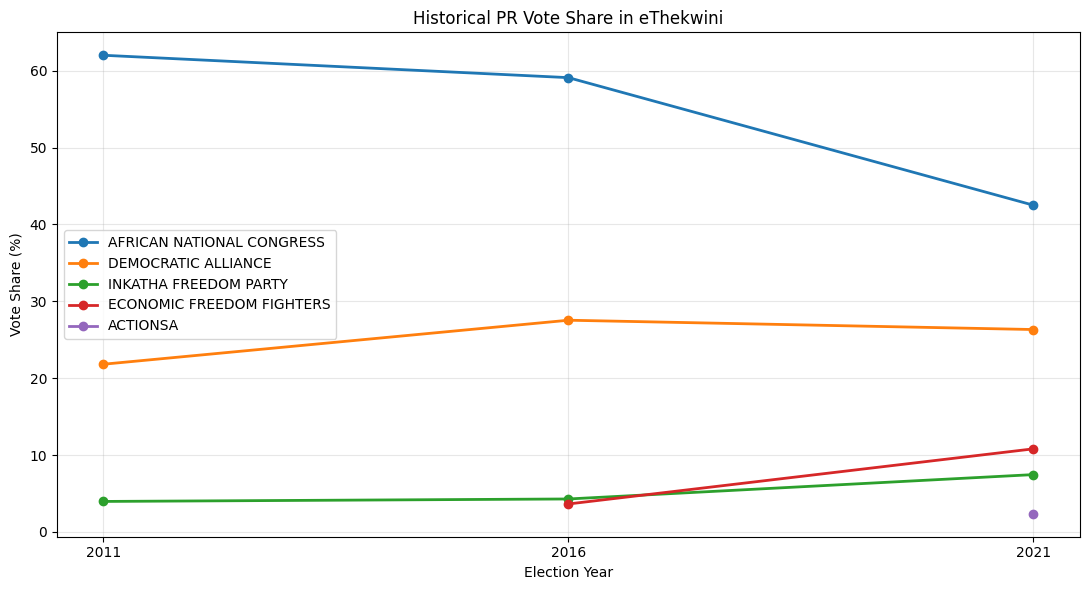

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

for party in major_parties:

    party_data = major_party_results[
        major_party_results["PartyName"] == party
    ].sort_values("ElectionYear")

    plt.plot(
        party_data["ElectionYear"],
        party_data["VoteShare"],
        marker="o",
        linewidth=2,
        label=party
    )

plt.title("Historical PR Vote Share in eThekwini")
plt.xlabel("Election Year")
plt.ylabel("Vote Share (%)")

plt.xticks([2011, 2016, 2021])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
# STEP 6.1: Inspect unique party names

for year, df in [
    (2011, election_2011_detail),
    (2016, election_2016_detail),
    (2021, election_2021_detail)
]:
    print(f"\n{'='*70}")
    print(f"PARTY NAMES - {year}")
    print("="*70)

    parties = sorted(df["PartyName"].dropna().astype(str).unique())

    print(f"Number of unique party names: {len(parties)}\n")

    for party in parties:
        print(party)


PARTY NAMES - 2011
Number of unique party names: 17

AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ALLIANSIE
AFRICAN CHRISTIAN DEMOCRATIC PARTY
AFRICAN NATIONAL CONGRESS
AFRICAN PEOPLE'S CONVENTION
AZANIAN PEOPLE'S ORGANISATION
BLACK CONSCIOUSNESS PARTY
CONGRESS  OF THE PEOPLE
DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE
INKATHA FREEDOM PARTY
MINORITY FRONT
NATIONAL FREEDOM PARTY
SOCIALIST GREEN COALITION
SOLIDARITY PARTY
TRULY ALLIANCE
UNITED ACTION FRONT
UNITED DEMOCRATIC MOVEMENT
VRYHEIDSFRONT PLUS

PARTY NAMES - 2016
Number of unique party names: 28

ACADEMIC CONGRESS UNION
AFRICAN CHRISTIAN DEMOCRATIC PARTY
AFRICAN INDEPENDENT CONGRESS
AFRICAN MANTUNGWA COMMUNITY
AFRICAN NATIONAL CONGRESS
AFRICAN PEOPLE'S CONVENTION
AL JAMA-AH
ALLIED MOVEMENT FOR CHANGE
AZANIAN PEOPLE'S ORGANISATION
CONGRESS  OF THE PEOPLE
DEMOCRATIC ALLIANCE
DEMOCRATIC LIBERAL CONGRESS
ECONOMIC FREEDOM FIGHTERS
INDEPENDENT
INDEPENDENT PEOPLE'S PARTY
INDEPENDENT RATEPAYERS ASSOCIATION OF SA
INKATHA FREEDOM PARTY
MI

In [ ]:
# STEP 6.2: Standardise party names across election years

datasets = {
    2011: election_2011_detail,
    2016: election_2016_detail,
    2021: election_2021_detail
}

# Clean spaces and convert party names to uppercase
for year, df in datasets.items():
    df["PartyName"] = (
        df["PartyName"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.upper()
    )

# Standardise known naming differences
party_name_mapping = {
    "DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE":
        "DEMOCRATIC ALLIANCE"
}

# Apply the standardisation
for year, df in datasets.items():
    df["PartyName"] = df["PartyName"].replace(party_name_mapping)

print("Party names successfully standardised.")

Party names successfully standardised.


In [ ]:
# STEP 6.3: Verify important party names across election years

major_parties = [
    "AFRICAN NATIONAL CONGRESS",
    "DEMOCRATIC ALLIANCE",
    "INKATHA FREEDOM PARTY",
    "ECONOMIC FREEDOM FIGHTERS",
    "NATIONAL FREEDOM PARTY",
    "MINORITY FRONT"
]

for year, df in datasets.items():

    print("\n" + "=" * 65)
    print(f"CHECKING PARTY NAMES - {year}")
    print("=" * 65)

    available_parties = df[
        df["PartyName"].isin(major_parties)
    ]["PartyName"].unique()

    for party in sorted(available_parties):
        print(party)


CHECKING PARTY NAMES - 2011
AFRICAN NATIONAL CONGRESS
DEMOCRATIC ALLIANCE
INKATHA FREEDOM PARTY
MINORITY FRONT
NATIONAL FREEDOM PARTY

CHECKING PARTY NAMES - 2016
AFRICAN NATIONAL CONGRESS
DEMOCRATIC ALLIANCE
ECONOMIC FREEDOM FIGHTERS
INKATHA FREEDOM PARTY
MINORITY FRONT

CHECKING PARTY NAMES - 2021
AFRICAN NATIONAL CONGRESS
DEMOCRATIC ALLIANCE
ECONOMIC FREEDOM FIGHTERS
INKATHA FREEDOM PARTY
MINORITY FRONT
NATIONAL FREEDOM PARTY


### Step 7: Combine Historical Election Data

The cleaned 2011, 2016 and 2021 eThekwini election datasets are combined into a single historical dataset.

Combining the election years makes it possible to compare party performance over time, identify changes in voter support, conduct exploratory data analysis, and prepare the historical data for the 2026 election forecasting stage.

A `Year` variable is added to preserve the election year associated with each observation.

In [ ]:
# STEP 7.2: Compare columns before combining datasets

for year, df in [
    (2011, election_2011_detail),
    (2016, election_2016_detail),
    (2021, election_2021_detail)
]:
    print("\n" + "=" * 70)
    print(f"COLUMNS - {year}")
    print("=" * 70)

    print(df.columns.tolist())
    print("Shape:", df.shape)


COLUMNS - 2011
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated', 'Year']
Shape: (13617, 12)

COLUMNS - 2016
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated', 'Year']
Shape: (40706, 12)

COLUMNS - 2021
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated', 'Year']
Shape: (43750, 12)


In [ ]:
# STEP 7.3: Combine 2011, 2016 and 2021 election datasets

election_combined = pd.concat(
    [
        election_2011_detail,
        election_2016_detail,
        election_2021_detail
    ],
    ignore_index=True
)

print("Historical election datasets successfully combined.")

print("\nCombined dataset shape:")
print(election_combined.shape)

print("\nRows per election year:")
print(election_combined["Year"].value_counts().sort_index())

Historical election datasets successfully combined.

Combined dataset shape:
(98073, 12)

Rows per election year:
Year
2011    13617
2016    40706
2021    43750
Name: count, dtype: int64


In [ ]:
# STEP 7.4: Inspect combined historical dataset

print("=" * 70)
print("COMBINED HISTORICAL ELECTION DATASET")
print("=" * 70)

print("\nDataset shape:")
print(election_combined.shape)

print("\nColumn names:")
print(election_combined.columns.tolist())

print("\nMissing values:")
print(election_combined.isnull().sum())

print("\nDuplicate rows:")
print(election_combined.duplicated().sum())

print("\nData types:")
print(election_combined.dtypes)

print("\nFirst 5 rows:")
display(election_combined.head())

COMBINED HISTORICAL ELECTION DATASET

Dataset shape:
(98073, 12)

Column names:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated', 'Year']

Missing values:
Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
Year                 0
dtype: int64

Duplicate rows:
0

Data types:
Province             object
Municipality         object
Ward                 object
VotingDistrict        int64
VotingStationName    object
RegisteredVoters      int64
BallotType           object
SpoiltVotes           int64
PartyName            object
TotalValidVotes       int64
DateGenerated        object
Year                  int64
dtype: object

First 5 rows:


,Province,Municipality,Ward,VotingDistrict,VotingStationName,RegisteredVoters,BallotType,SpoiltVotes,PartyName,TotalValidVotes,DateGenerated,Year
0,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1,5/26/2011 4:40:02 PM,2011
1,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0,5/26/2011 4:40:02 PM,2011
2,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN NATIONAL CONGRESS,973,5/26/2011 4:40:02 PM,2011
3,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AFRICAN PEOPLE'S CONVENTION,2,5/26/2011 4:40:02 PM,2011
4,KwaZulu-Natal,ETH - eThekwini [Durban Metro],Ward 59500001,43400179,NOMFIHLELA PRIMARY SCHOOL,1438,PR,26,AZANIAN PEOPLE'S ORGANISATION,1,5/26/2011 4:40:02 PM,2011


### Step 8: Validate Ballot Types and Key Election Variables

Before calculating historical party performance, the combined dataset is examined to understand the ballot types and key voting variables.

South African local government election data may contain different ballot types, such as proportional representation (PR) and ward ballots. These must be identified before aggregation to avoid incorrectly combining votes from different ballot categories.

The distributions of ballot types, election years and registered voters are therefore validated before exploratory analysis.

In [ ]:
# STEP 8.1: Inspect ballot types by election year

print("=" * 70)
print("BALLOT TYPES BY ELECTION YEAR")
print("=" * 70)

ballot_types = pd.crosstab(
    election_combined["Year"],
    election_combined["BallotType"]
)

display(ballot_types)

print("\nUnique ballot types:")
print(election_combined["BallotType"].unique())

BALLOT TYPES BY ELECTION YEAR


BallotType,PR,Ward
Year,,
2011,13617,0
2016,23382,17324
2021,43750,0



Unique ballot types:
['PR' 'Ward']


In [ ]:
# STEP 8.2: Summary statistics for key numeric variables

numeric_summary = election_combined[
    [
        "RegisteredVoters",
        "SpoiltVotes",
        "TotalValidVotes"
    ]
].describe()

display(numeric_summary)

,RegisteredVoters,SpoiltVotes,TotalValidVotes
count,98073.000000,98073.000000,98073.000000
mean,2182.898117,23.868496,40.521540
std,1194.299631,37.401222,191.101062
min,101.000000,0.000000,0.000000
25%,1353.000000,6.000000,0.000000
50%,2060.000000,15.000000,1.000000
75%,2811.000000,29.000000,4.000000
max,8099.000000,993.000000,4175.000000


In [ ]:
# STEP 8.3: Check total recorded party votes by year and ballot type

vote_check = (
    election_combined
    .groupby(["Year", "BallotType"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

display(vote_check)

,Year,BallotType,TotalValidVotes
0,2011,PR,973728
1,2016,PR,1104552
2,2016,Ward,1121053
3,2021,PR,774736


### Selection of a Consistent Ballot Type

The ballot-type validation showed that proportional representation (PR) records are available for all three historical election years (2011, 2016 and 2021), while Ward ballot records are present only in the 2016 dataset used in this analysis.

To maintain comparability across election years, the longitudinal party-level analysis therefore uses PR ballot records only. Including the available 2016 Ward records would make the 2016 observations structurally inconsistent with the 2011 and 2021 datasets and could distort historical party trends.

The original combined dataset is retained, while a separate PR-only analytical dataset is created for subsequent party-level exploratory analysis and modelling.

In [ ]:
# STEP 8.4: Create PR-only analytical dataset

election_pr = election_combined[
    election_combined["BallotType"] == "PR"
].copy()

print("=" * 70)
print("PR-ONLY ANALYTICAL DATASET")
print("=" * 70)

print("\nShape:")
print(election_pr.shape)

print("\nRows by year:")
print(election_pr["Year"].value_counts().sort_index())

print("\nTotal PR votes by year:")
print(
    election_pr
    .groupby("Year")["TotalValidVotes"]
    .sum()
)

PR-ONLY ANALYTICAL DATASET

Shape:
(80749, 12)

Rows by year:
Year
2011    13617
2016    23382
2021    43750
Name: count, dtype: int64

Total PR votes by year:
Year
2011     973728
2016    1104552
2021     774736
Name: TotalValidVotes, dtype: int64


### Step 9: Construct Historical Party-Level Performance Data

The PR voting-station records are aggregated by election year and political party to create a historical party-performance dataset.

For each party and election year, total party votes are calculated. The total number of PR votes cast in each election year is then used to calculate each party's percentage vote share.

Vote share is particularly useful for comparing elections because the total number of votes cast differs between election years.

In [ ]:
# STEP 9.1: Aggregate PR votes by party and election year

party_year = (
    election_pr
    .groupby(["Year", "PartyName"], as_index=False)
    ["TotalValidVotes"]
    .sum()
)

party_year = party_year.rename(
    columns={"TotalValidVotes": "PartyVotes"}
)

# Calculate total PR votes in each election year
year_totals = (
    party_year
    .groupby("Year")["PartyVotes"]
    .transform("sum")
)

# Calculate percentage vote share
party_year["VoteShare"] = (
    party_year["PartyVotes"] / year_totals
) * 100

# Sort logically
party_year = party_year.sort_values(
    ["Year", "PartyVotes"],
    ascending=[True, False]
).reset_index(drop=True)

display(party_year.head(20))

,Year,PartyName,PartyVotes,VoteShare
0,2011,AFRICAN NATIONAL CONGRESS,603929,62.022351
1,2011,DEMOCRATIC ALLIANCE,212409,21.813997
2,2011,MINORITY FRONT,48064,4.936081
3,2011,NATIONAL FREEDOM PARTY,43606,4.478253
4,2011,INKATHA FREEDOM PARTY,38532,3.957163
5,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6555,0.673186
6,2011,TRULY ALLIANCE,6026,0.618859
7,2011,AFRICAN PEOPLE'S CONVENTION,3970,0.407711
8,2011,CONGRESS OF THE PEOPLE,3882,0.398674
9,2011,UNITED ACTION FRONT,1256,0.128989


In [ ]:
# STEP 9.2: Validate party-level dataset

print("=" * 70)
print("PARTY-LEVEL HISTORICAL DATA VALIDATION")
print("=" * 70)

print("\nDataset shape:")
print(party_year.shape)

print("\nVote-share total for each year:")
print(
    party_year
    .groupby("Year")["VoteShare"]
    .sum()
    .round(2)
)

print("\nNumber of parties by year:")
print(
    party_year
    .groupby("Year")["PartyName"]
    .nunique()
)

print("\nTop 10 parties in each election:")
for year in sorted(party_year["Year"].unique()):

    print("\n" + "=" * 70)
    print(f"TOP 10 PARTIES - {year}")
    print("=" * 70)

    top10 = (
        party_year[party_year["Year"] == year]
        .nlargest(10, "PartyVotes")
        [["PartyName", "PartyVotes", "VoteShare"]]
        .copy()
    )

    top10["VoteShare"] = top10["VoteShare"].round(2)

    display(top10)

PARTY-LEVEL HISTORICAL DATA VALIDATION

Dataset shape:
(94, 4)

Vote-share total for each year:
Year
2011    100.0
2016    100.0
2021    100.0
Name: VoteShare, dtype: float64

Number of parties by year:
Year
2011    17
2016    27
2021    50
Name: PartyName, dtype: int64

Top 10 parties in each election:

TOP 10 PARTIES - 2011


,PartyName,PartyVotes,VoteShare
0,AFRICAN NATIONAL CONGRESS,603929,62.02
1,DEMOCRATIC ALLIANCE,212409,21.81
2,MINORITY FRONT,48064,4.94
3,NATIONAL FREEDOM PARTY,43606,4.48
4,INKATHA FREEDOM PARTY,38532,3.96
5,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6555,0.67
6,TRULY ALLIANCE,6026,0.62
7,AFRICAN PEOPLE'S CONVENTION,3970,0.41
8,CONGRESS OF THE PEOPLE,3882,0.40
9,UNITED ACTION FRONT,1256,0.13



TOP 10 PARTIES - 2016


,PartyName,PartyVotes,VoteShare
17,AFRICAN NATIONAL CONGRESS,652891,59.11
18,DEMOCRATIC ALLIANCE,304206,27.54
19,INKATHA FREEDOM PARTY,47260,4.28
20,ECONOMIC FREEDOM FIGHTERS,40087,3.63
21,AFRICAN INDEPENDENT CONGRESS,16673,1.51
22,AFRICAN CHRISTIAN DEMOCRATIC PARTY,5956,0.54
23,MINORITY FRONT,5070,0.46
24,DEMOCRATIC LIBERAL CONGRESS,4801,0.43
25,TRULY ALLIANCE,4686,0.42
26,MINORITIES OF SOUTH AFRICA,3018,0.27



TOP 10 PARTIES - 2021


,PartyName,PartyVotes,VoteShare
44,AFRICAN NATIONAL CONGRESS,329307,42.51
45,DEMOCRATIC ALLIANCE,203980,26.33
46,ECONOMIC FREEDOM FIGHTERS,83699,10.80
47,INKATHA FREEDOM PARTY,57722,7.45
48,ACTIONSA,18201,2.35
49,AFRICAN INDEPENDENT CONGRESS,7809,1.01
50,ACTIVE CITIZENS COALITION,6239,0.81
51,AFRICAN CHRISTIAN DEMOCRATIC PARTY,5893,0.76
52,ABANTU BATHO CONGRESS,4998,0.65
53,JUSTICE AND EMPLOYMENT PARTY,4763,0.61


## Step 10: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand historical voting patterns in eThekwini before developing the 2026 election forecasting model.

The analysis examines party vote shares, changes in voter support across election years, distributions of voting variables, and relationships between relevant numerical features.

Visualisations used include bar charts, histograms, trend plots, scatter plots and a correlation heatmap. Each visualisation is selected according to the type of relationship or distribution being investigated.

### 10.1 Party Vote Share by Election Year

A bar chart is used to compare the vote shares of the leading political parties in each historical election. This helps identify the dominant parties in eThekwini and changes in their relative electoral support.

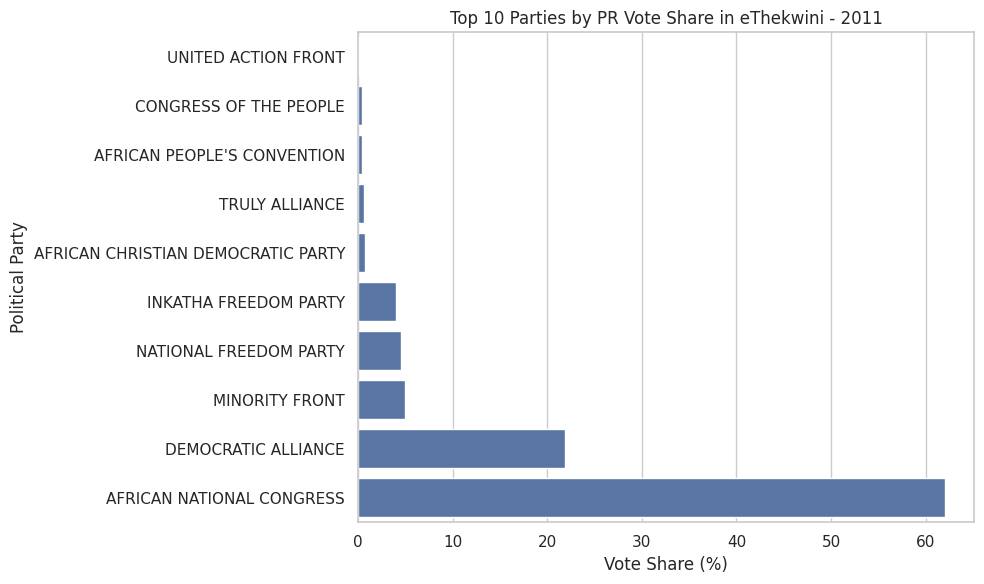

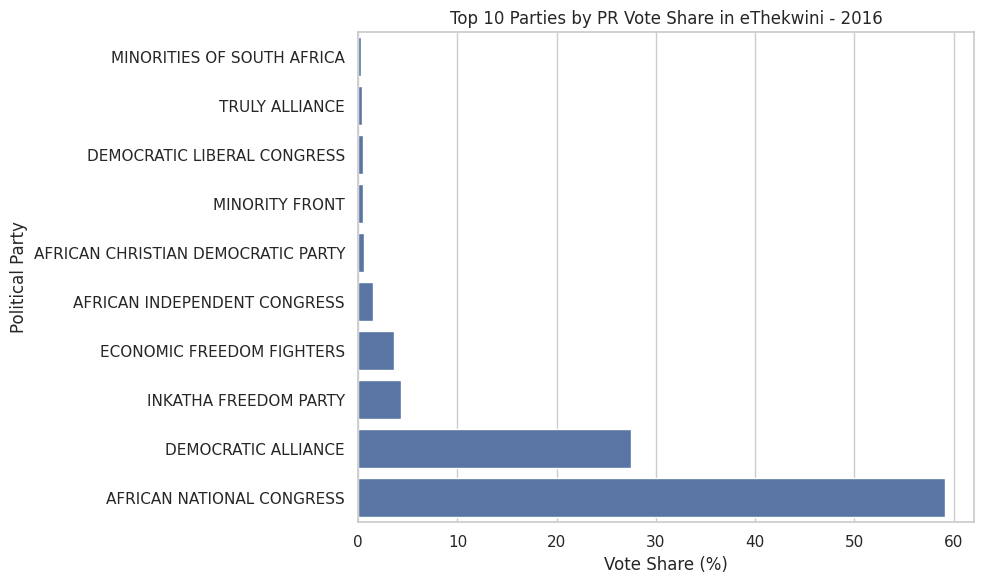

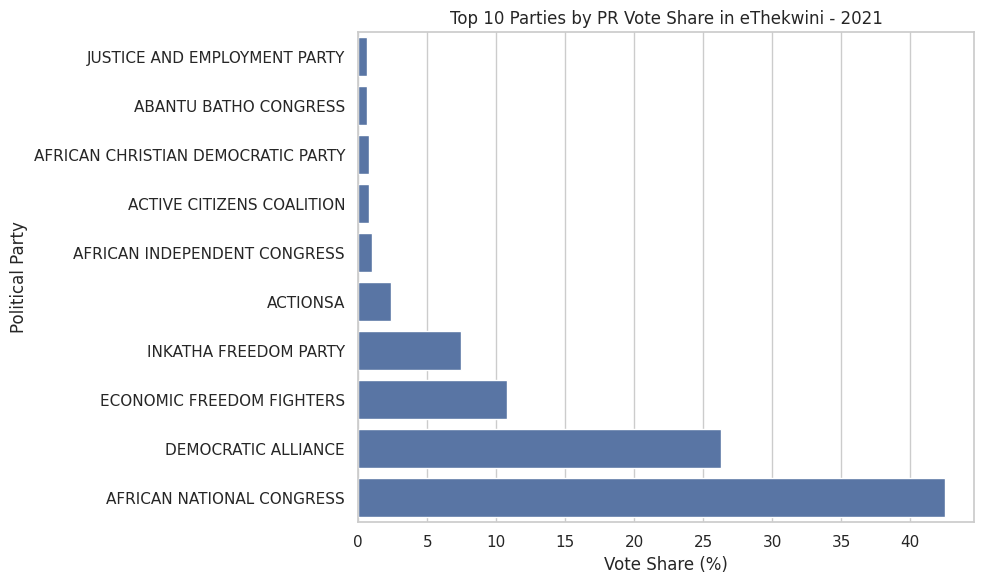

In [ ]:
# STEP 10.1: Bar graphs of top 10 parties by election year

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

for year in sorted(party_year["Year"].unique()):

    top10 = (
        party_year[party_year["Year"] == year]
        .nlargest(10, "VoteShare")
        .sort_values("VoteShare", ascending=True)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=top10,
        x="VoteShare",
        y="PartyName"
    )

    plt.title(f"Top 10 Parties by PR Vote Share in eThekwini - {year}")
    plt.xlabel("Vote Share (%)")
    plt.ylabel("Political Party")

    plt.tight_layout()
    plt.show()

### 10.2 Historical Vote Share Trends of Major Parties

Historical vote-share trends are examined for major political parties in eThekwini. A line chart is appropriate because election year is an ordered time variable and the objective is to observe how party support has changed between elections.

Parties that did not contest or do not have an observation in a particular historical election are not automatically treated as having zero support unless supported by the source data.

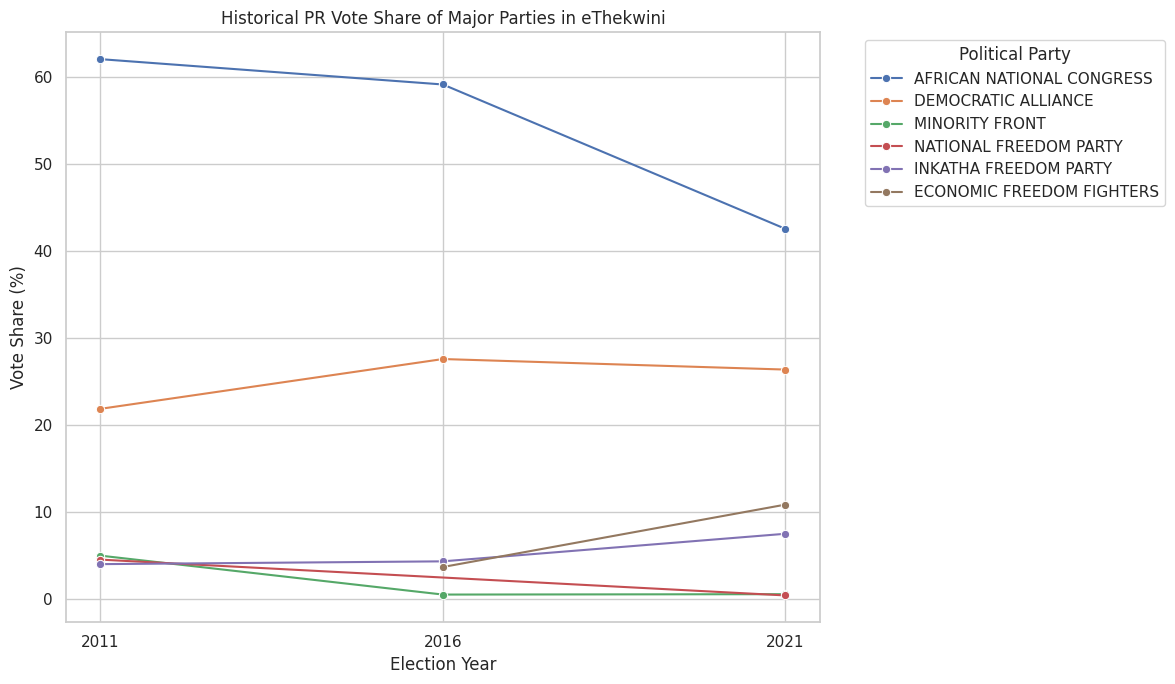

In [ ]:
# STEP 10.2: Historical vote-share trends for major parties

major_parties = [
    "AFRICAN NATIONAL CONGRESS",
    "DEMOCRATIC ALLIANCE",
    "ECONOMIC FREEDOM FIGHTERS",
    "INKATHA FREEDOM PARTY",
    "NATIONAL FREEDOM PARTY",
    "MINORITY FRONT"
]

trend_data = party_year[
    party_year["PartyName"].isin(major_parties)
].copy()

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=trend_data,
    x="Year",
    y="VoteShare",
    hue="PartyName",
    marker="o"
)

plt.title("Historical PR Vote Share of Major Parties in eThekwini")
plt.xlabel("Election Year")
plt.ylabel("Vote Share (%)")

plt.xticks([2011, 2016, 2021])

plt.legend(
    title="Political Party",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### 10.3 Distribution of Party Votes at Voting-Station Level

A histogram is used to examine the distribution of PR votes received by parties across voting-station records.

This analysis helps determine whether party vote counts are evenly distributed or concentrated among a smaller number of high-performing party-station observations. Understanding the distribution is useful before modelling because highly skewed variables can influence statistical and machine-learning methods.

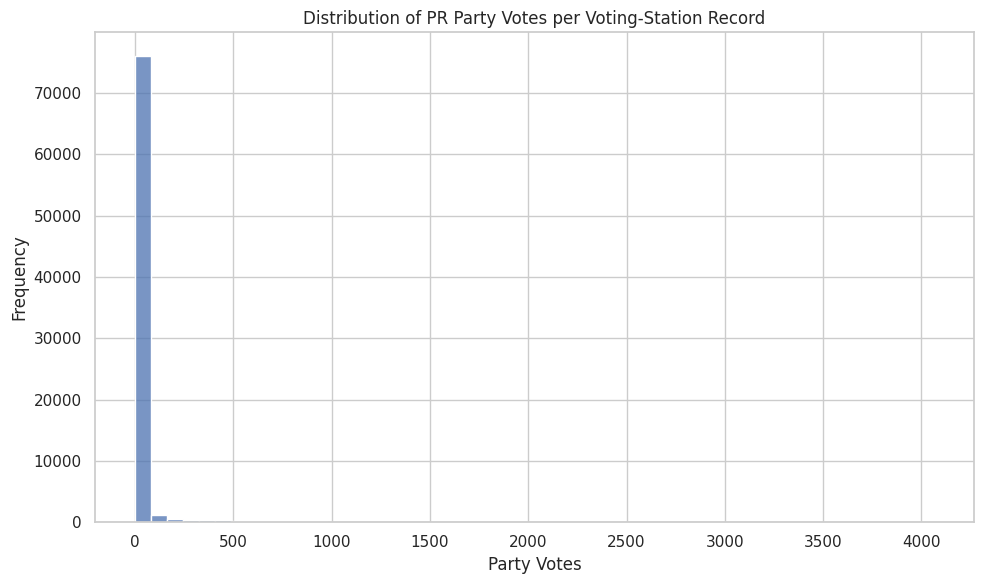

In [ ]:
# STEP 10.3: Histogram of PR party votes at voting-station level

plt.figure(figsize=(10, 6))

sns.histplot(
    data=election_pr,
    x="TotalValidVotes",
    bins=50
)

plt.title("Distribution of PR Party Votes per Voting-Station Record")
plt.xlabel("Party Votes")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 10.4 Relationship Between Registered Voters and Party Votes

A scatter plot is used to examine the relationship between the number of registered voters associated with a voting station and the number of votes received by individual parties.

This visualisation helps determine whether larger registered-voter populations are associated with higher party vote counts and whether substantial variation exists between voting-station observations.

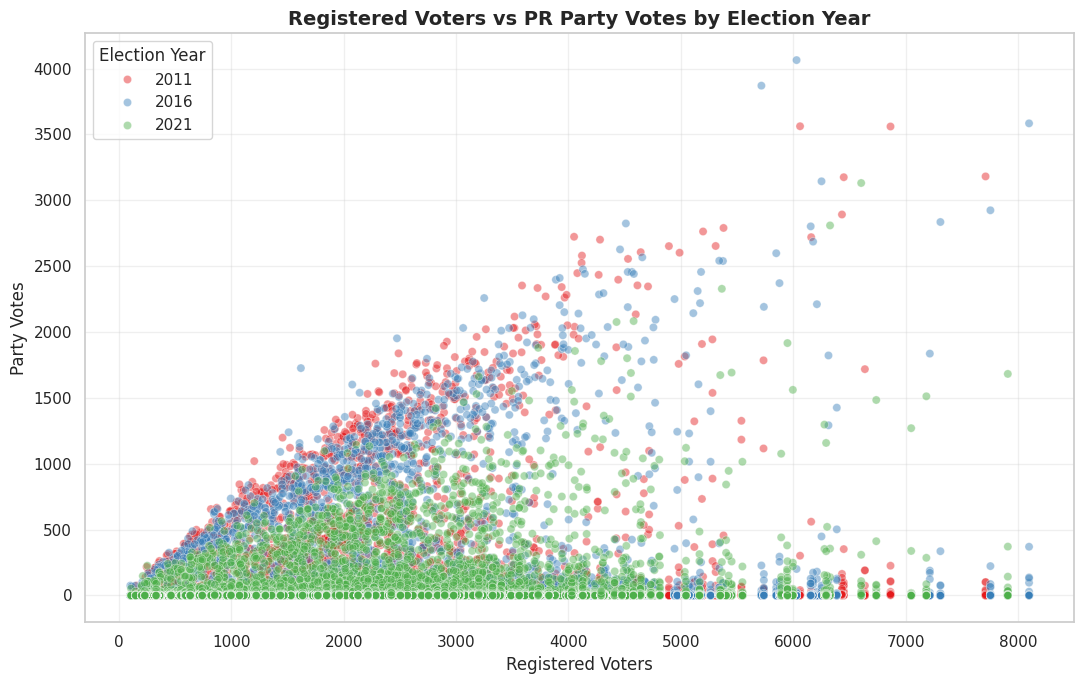

In [ ]:
# STEP 10.4: Scatter plot using different colours for election years

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=election_pr,
    x="RegisteredVoters",
    y="TotalValidVotes",
    hue="Year",                 # Different colour for each election year
    palette="Set1",
    alpha=0.45,
    s=35
)

plt.title(
    "Registered Voters vs PR Party Votes by Election Year",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Registered Voters")
plt.ylabel("Party Votes")

plt.legend(
    title="Election Year"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 10.5 Correlation Analysis of Numerical Election Variables

A correlation matrix is used to examine the linear relationships between numerical variables in the historical PR election data.

The analysis includes registered voters, spoilt votes, party-level valid votes and election year. Correlation coefficients range from -1 to +1, where values closer to +1 indicate a stronger positive linear relationship, values closer to -1 indicate a stronger negative relationship, and values near zero indicate a weak linear relationship.

Correlation does not imply causation; therefore, the results are interpreted only as associations within the available historical election data.

Correlation Matrix:


,RegisteredVoters,SpoiltVotes,TotalValidVotes,Year
RegisteredVoters,1.000,0.247,0.094,0.022
SpoiltVotes,0.247,1.000,0.025,-0.015
TotalValidVotes,0.094,0.025,1.000,-0.117
Year,0.022,-0.015,-0.117,1.000


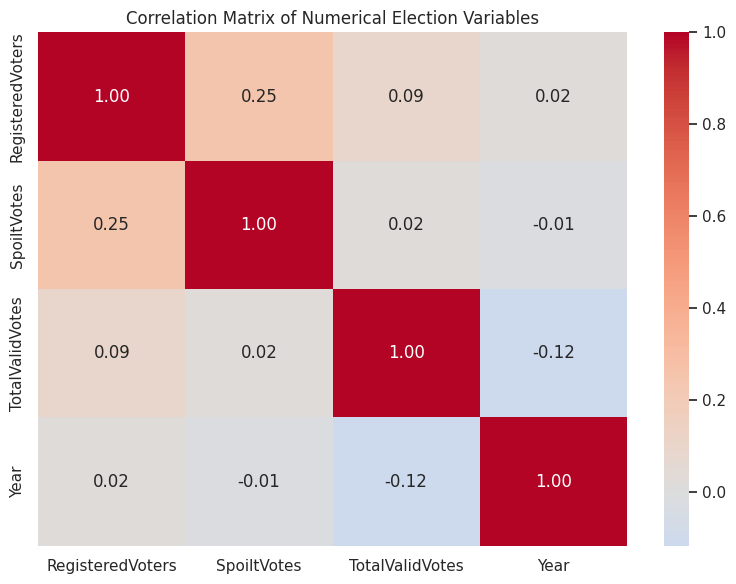

In [ ]:
# STEP 10.5: Correlation matrix for numerical election variables

correlation_data = election_pr[
    [
        "RegisteredVoters",
        "SpoiltVotes",
        "TotalValidVotes",
        "Year"
    ]
]

correlation_matrix = correlation_data.corr()

print("Correlation Matrix:")
display(correlation_matrix.round(3))

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Election Variables")

plt.tight_layout()
plt.show()

### 10.6 Interpretation of Exploratory Data Analysis

The exploratory analysis revealed several important patterns in the historical eThekwini election data.

The party vote-share analysis shows substantial changes in political support across the three historical elections. The African National Congress (ANC) remained the largest party in all three elections, but its PR vote share declined from approximately 62.02% in 2011 to 59.11% in 2016 and 42.51% in 2021. The Democratic Alliance (DA) increased from approximately 21.81% in 2011 to 27.54% in 2016 before decreasing slightly to 26.33% in 2021.

The Economic Freedom Fighters (EFF), which has observations from 2016 onward in the dataset, increased from approximately 3.63% in 2016 to 10.80% in 2021. The Inkatha Freedom Party (IFP) also increased its vote share over the historical period.

The bar charts demonstrate that eThekwini's party-support distribution changed considerably between elections, while the historical trend plot highlights different trajectories among the major parties.

The voting-station-level analysis also shows considerable variation in party vote counts. The scatter plot indicates that stations with larger numbers of registered voters can produce larger party vote counts, although there is substantial dispersion because individual parties receive different levels of support at each station.

The correlation matrix shows generally weak linear relationships between the numerical variables. Registered voters and spoilt votes have the strongest observed positive correlation at approximately 0.25. Registered voters and individual party valid votes have a weak positive correlation of approximately 0.09. Election year and individual party valid votes have a weak negative correlation of approximately -0.12.

These results indicate that simple numerical relationships alone are unlikely to explain party performance adequately. Historical party identity, previous vote share and changes in party support over time are therefore likely to be more informative for the forecasting stage.

## Step 11: Feature Engineering for Election Forecasting

Feature engineering is performed to transform the historical party-level election results into variables that can be used for modelling.

Because the objective is to estimate party performance in the 2026 eThekwini local government election, historical vote share is used as the primary measure of party support rather than raw vote totals. Raw vote totals can be affected by changes in turnout and the number of participating voters between elections.

For parties with sufficient historical observations, additional features are created to represent previous vote share and the change in support between consecutive elections.

The historical dataset contains only three municipal election years (2011, 2016 and 2021). Therefore, the resulting forecasting model must be interpreted cautiously, and the 2026 results will be presented as model estimates rather than known future outcomes.

In [ ]:
# STEP 11.1: Create previous vote-share feature

model_data = party_year.copy()

model_data = model_data.sort_values(
    ["PartyName", "Year"]
).reset_index(drop=True)

model_data["PreviousVoteShare"] = (
    model_data
    .groupby("PartyName")["VoteShare"]
    .shift(1)
)

print("=" * 70)
print("PREVIOUS VOTE SHARE FEATURE")
print("=" * 70)

display(
    model_data[
        [
            "Year",
            "PartyName",
            "VoteShare",
            "PreviousVoteShare"
        ]
    ].head(30)
)

PREVIOUS VOTE SHARE FEATURE


,Year,PartyName,VoteShare,PreviousVoteShare
0,2021,ABANTU BATHO CONGRESS,0.645123,NaN
1,2016,ACADEMIC CONGRESS UNION,0.044000,NaN
2,2021,ACADEMIC CONGRESS UNION,0.048920,0.044000
3,2021,ACTIONSA,2.349316,NaN
4,2021,ACTIVE CITIZENS COALITION,0.805307,NaN
5,2021,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0.077833,NaN
6,2021,ADVANCED DYNAMIC ALLIANCE,0.062086,NaN
7,2021,AFRICA RESTORATION ALLIANCE,0.026202,NaN
8,2021,AFRICAN BASIC REPUBLICANS,0.026719,NaN
9,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,0.097460,NaN


### 11.2 Historical Change in Party Support

The change in party support between consecutive observed elections is calculated as the current vote share minus the party's previous observed vote share.

A positive value represents an increase in vote share, while a negative value represents a decrease. This feature helps quantify the historical direction and magnitude of changes in party support.

In [ ]:
# STEP 11.2: Calculate change in vote share

model_data["VoteShareChange"] = (
    model_data["VoteShare"]
    - model_data["PreviousVoteShare"]
)

display(
    model_data[
        [
            "Year",
            "PartyName",
            "VoteShare",
            "PreviousVoteShare",
            "VoteShareChange"
        ]
    ].head(30)
)

,Year,PartyName,VoteShare,PreviousVoteShare,VoteShareChange
0,2021,ABANTU BATHO CONGRESS,0.645123,NaN,NaN
1,2016,ACADEMIC CONGRESS UNION,0.044000,NaN,NaN
2,2021,ACADEMIC CONGRESS UNION,0.048920,0.044000,0.004920
3,2021,ACTIONSA,2.349316,NaN,NaN
4,2021,ACTIVE CITIZENS COALITION,0.805307,NaN,NaN
5,2021,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0.077833,NaN,NaN
6,2021,ADVANCED DYNAMIC ALLIANCE,0.062086,NaN,NaN
7,2021,AFRICA RESTORATION ALLIANCE,0.026202,NaN,NaN
8,2021,AFRICAN BASIC REPUBLICANS,0.026719,NaN,NaN
9,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,0.097460,NaN,NaN


In [ ]:
# STEP 11.3: Count historical election observations for each party

party_history_count = (
    party_year
    .groupby("PartyName")["Year"]
    .nunique()
    .sort_values(ascending=False)
)

print("=" * 70)
print("NUMBER OF HISTORICAL ELECTIONS PER PARTY")
print("=" * 70)

display(party_history_count.to_frame("ElectionCount"))

NUMBER OF HISTORICAL ELECTIONS PER PARTY


,ElectionCount
PartyName,
AFRICAN CHRISTIAN DEMOCRATIC PARTY,3
AZANIAN PEOPLE'S ORGANISATION,3
CONGRESS OF THE PEOPLE,3
AFRICAN PEOPLE'S CONVENTION,3
AFRICAN NATIONAL CONGRESS,3
...,...
UNITED ACTION FRONT,1
UNITED CULTURAL MOVEMENT,1
UNITED INDEPENDENT MOVEMENT,1


In [ ]:
# Parties represented in all three historical elections

three_election_parties = party_history_count[
    party_history_count == 3
].index.tolist()

print("Parties appearing in all three elections:")
print("Number of parties:", len(three_election_parties))

for party in three_election_parties:
    print("-", party)

Parties appearing in all three elections:
Number of parties: 10
- AFRICAN CHRISTIAN DEMOCRATIC PARTY
- AZANIAN PEOPLE'S ORGANISATION
- CONGRESS OF THE PEOPLE
- AFRICAN PEOPLE'S CONVENTION
- AFRICAN NATIONAL CONGRESS
- DEMOCRATIC ALLIANCE
- VRYHEIDSFRONT PLUS
- MINORITY FRONT
- INKATHA FREEDOM PARTY
- TRULY ALLIANCE


## Step 12: Preparation of the Modelling Dataset

The historical data shows that 61 different political parties appear across the 2011, 2016 and 2021 datasets, but only 10 parties have observations in all three elections.

For the primary forecasting model, parties with observations in all three historical elections are used to create a consistent modelling dataset. This avoids treating the absence of a party from an earlier dataset as if it had received zero votes.

Parties with shorter histories, such as parties that entered the electoral competition after 2011, are retained for separate consideration and are not automatically assigned fabricated historical observations.

Because only three historical municipal election periods are available, model complexity is deliberately limited to reduce the risk of overfitting.

In [ ]:
# STEP 12.1: Create dataset for parties observed in all 3 elections

consistent_parties_data = (
    party_year[
        party_year["PartyName"].isin(three_election_parties)
    ]
    .copy()
    .sort_values(["PartyName", "Year"])
    .reset_index(drop=True)
)

print("=" * 70)
print("CONSISTENT-PARTY MODELLING DATASET")
print("=" * 70)

print("\nShape:")
print(consistent_parties_data.shape)

print("\nNumber of parties:")
print(consistent_parties_data["PartyName"].nunique())

print("\nElection years:")
print(sorted(consistent_parties_data["Year"].unique()))

display(consistent_parties_data)

CONSISTENT-PARTY MODELLING DATASET

Shape:
(30, 4)

Number of parties:
10

Election years:
[np.int64(2011), np.int64(2016), np.int64(2021)]


,Year,PartyName,PartyVotes,VoteShare
0,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6555,0.673186
1,2016,AFRICAN CHRISTIAN DEMOCRATIC PARTY,5956,0.539223
2,2021,AFRICAN CHRISTIAN DEMOCRATIC PARTY,5893,0.760646
3,2011,AFRICAN NATIONAL CONGRESS,603929,62.022351
4,2016,AFRICAN NATIONAL CONGRESS,652891,59.109123
5,2021,AFRICAN NATIONAL CONGRESS,329307,42.505705
6,2011,AFRICAN PEOPLE'S CONVENTION,3970,0.407711
7,2016,AFRICAN PEOPLE'S CONVENTION,2922,0.264542
8,2021,AFRICAN PEOPLE'S CONVENTION,962,0.124171
9,2011,AZANIAN PEOPLE'S ORGANISATION,1238,0.127140


### 12.2 Historical Vote-Share Modelling Matrix

The consistent party-level data is reshaped so that each row represents a political party and each column represents an election year.

This provides a compact representation of historical party trajectories and allows changes between consecutive elections to be calculated directly.

In [ ]:
# STEP 12.2: Create historical vote-share matrix

vote_share_matrix = (
    consistent_parties_data
    .pivot(
        index="PartyName",
        columns="Year",
        values="VoteShare"
    )
)

vote_share_matrix = vote_share_matrix.round(3)

display(vote_share_matrix)

Year,2011,2016,2021
PartyName,,,
AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.673,0.539,0.761
AFRICAN NATIONAL CONGRESS,62.022,59.109,42.506
AFRICAN PEOPLE'S CONVENTION,0.408,0.265,0.124
AZANIAN PEOPLE'S ORGANISATION,0.127,0.043,0.034
CONGRESS OF THE PEOPLE,0.399,0.142,0.116
DEMOCRATIC ALLIANCE,21.814,27.541,26.329
INKATHA FREEDOM PARTY,3.957,4.279,7.451
MINORITY FRONT,4.936,0.459,0.503
TRULY ALLIANCE,0.619,0.424,0.242


In [ ]:
# STEP 12.3: Calculate historical vote-share changes

forecast_features = vote_share_matrix.copy()

forecast_features["Change_2011_2016"] = (
    forecast_features[2016]
    - forecast_features[2011]
)

forecast_features["Change_2016_2021"] = (
    forecast_features[2021]
    - forecast_features[2016]
)

forecast_features["AverageChange"] = (
    forecast_features[
        ["Change_2011_2016", "Change_2016_2021"]
    ]
    .mean(axis=1)
)

display(forecast_features.round(3))

Year,2011,2016,2021,Change_2011_2016,Change_2016_2021,AverageChange
PartyName,,,,,,
AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.673,0.539,0.761,-0.134,0.222,0.044
AFRICAN NATIONAL CONGRESS,62.022,59.109,42.506,-2.913,-16.603,-9.758
AFRICAN PEOPLE'S CONVENTION,0.408,0.265,0.124,-0.143,-0.141,-0.142
AZANIAN PEOPLE'S ORGANISATION,0.127,0.043,0.034,-0.084,-0.009,-0.046
CONGRESS OF THE PEOPLE,0.399,0.142,0.116,-0.257,-0.026,-0.142
DEMOCRATIC ALLIANCE,21.814,27.541,26.329,5.727,-1.212,2.258
INKATHA FREEDOM PARTY,3.957,4.279,7.451,0.322,3.172,1.747
MINORITY FRONT,4.936,0.459,0.503,-4.477,0.044,-2.217
TRULY ALLIANCE,0.619,0.424,0.242,-0.195,-0.182,-0.188


### 12.4 Baseline Forecasting Method

A naive baseline is established before fitting a more complex forecasting model.

For the baseline, a party's vote share in the previous election is used as the prediction for the following election. For example, the 2016 vote share is used as a naive prediction of the 2021 vote share.

The baseline provides a benchmark against which alternative forecasting methods can be evaluated. A more complex model should only be preferred if it provides a meaningful improvement over this simple approach.

In [ ]:
# STEP 12.4: Naive baseline backtest
# Use 2016 vote share as prediction for 2021

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual_2021 = forecast_features[2021]

naive_prediction_2021 = forecast_features[2016]

naive_mae = mean_absolute_error(
    actual_2021,
    naive_prediction_2021
)

naive_rmse = np.sqrt(
    mean_squared_error(
        actual_2021,
        naive_prediction_2021
    )
)

print("=" * 70)
print("NAIVE BASELINE - 2021 BACKTEST")
print("=" * 70)

print(f"MAE:  {naive_mae:.3f} percentage points")
print(f"RMSE: {naive_rmse:.3f} percentage points")

NAIVE BASELINE - 2021 BACKTEST
MAE:  2.177 percentage points
RMSE: 5.360 percentage points


In [ ]:
# Compare baseline predictions with actual 2021 results

baseline_comparison = pd.DataFrame({
    "Party": forecast_features.index,
    "Actual_2021": actual_2021.values,
    "Predicted_2021": naive_prediction_2021.values
})

baseline_comparison["AbsoluteError"] = abs(
    baseline_comparison["Actual_2021"]
    - baseline_comparison["Predicted_2021"]
)

baseline_comparison = baseline_comparison.sort_values(
    "AbsoluteError",
    ascending=False
)

display(baseline_comparison.round(3))

,Party,Actual_2021,Predicted_2021,AbsoluteError
1,AFRICAN NATIONAL CONGRESS,42.506,59.109,16.603
6,INKATHA FREEDOM PARTY,7.451,4.279,3.172
5,DEMOCRATIC ALLIANCE,26.329,27.541,1.212
0,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.761,0.539,0.222
8,TRULY ALLIANCE,0.242,0.424,0.182
9,VRYHEIDSFRONT PLUS,0.261,0.102,0.159
2,AFRICAN PEOPLE'S CONVENTION,0.124,0.265,0.141
7,MINORITY FRONT,0.503,0.459,0.044
4,CONGRESS OF THE PEOPLE,0.116,0.142,0.026
3,AZANIAN PEOPLE'S ORGANISATION,0.034,0.043,0.009


## Step 13: Forecast Model Development and Historical Backtesting

Candidate forecasting approaches are evaluated using historical backtesting before producing the 2026 election estimate.

The 2021 election is treated as an unseen future election. Models are constructed using only information available from the 2011 and 2016 elections and are then used to predict 2021 party vote share. The predictions are compared with the actual 2021 results using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

This time-based evaluation is preferred to a random train-test split because election observations are chronological. Randomly mixing election years could introduce future information into model training.

Given the very small number of historical election periods, simple and interpretable forecasting approaches are preferred over highly complex machine-learning models that would be prone to overfitting.

### 13.1 Linear Trend Extrapolation

A simple linear-trend model is evaluated as the first candidate forecasting approach.

Because the historical municipal elections occur at five-year intervals, the change in vote share between 2011 and 2016 is projected forward by one election period to obtain a prediction for 2021.

The predicted 2021 results are then compared with the actual 2021 results. This provides a historical backtest of whether short-term vote-share trends would have been useful for forecasting the subsequent election.

In [ ]:
# STEP 13.1: Linear trend backtest for 2021

linear_backtest = forecast_features.copy()

# Change observed between 2011 and 2016
linear_backtest["HistoricalChange"] = (
    linear_backtest[2016] - linear_backtest[2011]
)

# Project that same change from 2016 to 2021
linear_backtest["Predicted_2021"] = (
    linear_backtest[2016]
    + linear_backtest["HistoricalChange"]
)

# Vote share cannot be negative
linear_backtest["Predicted_2021"] = (
    linear_backtest["Predicted_2021"].clip(lower=0)
)

linear_backtest["Actual_2021"] = linear_backtest[2021]

linear_backtest["AbsoluteError"] = abs(
    linear_backtest["Actual_2021"]
    - linear_backtest["Predicted_2021"]
)

display(
    linear_backtest[
        [
            2011,
            2016,
            "Predicted_2021",
            "Actual_2021",
            "AbsoluteError"
        ]
    ].round(3)
)

Year,2011,2016,Predicted_2021,Actual_2021,AbsoluteError
PartyName,,,,,
AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.673,0.539,0.405,0.761,0.356
AFRICAN NATIONAL CONGRESS,62.022,59.109,56.196,42.506,13.690
AFRICAN PEOPLE'S CONVENTION,0.408,0.265,0.122,0.124,0.002
AZANIAN PEOPLE'S ORGANISATION,0.127,0.043,0.000,0.034,0.034
CONGRESS OF THE PEOPLE,0.399,0.142,0.000,0.116,0.116
DEMOCRATIC ALLIANCE,21.814,27.541,33.268,26.329,6.939
INKATHA FREEDOM PARTY,3.957,4.279,4.601,7.451,2.850
MINORITY FRONT,4.936,0.459,0.000,0.503,0.503
TRULY ALLIANCE,0.619,0.424,0.229,0.242,0.013


In [ ]:
# STEP 13.2: Evaluate linear trend model

linear_mae = mean_absolute_error(
    linear_backtest["Actual_2021"],
    linear_backtest["Predicted_2021"]
)

linear_rmse = np.sqrt(
    mean_squared_error(
        linear_backtest["Actual_2021"],
        linear_backtest["Predicted_2021"]
    )
)

print("=" * 70)
print("LINEAR TREND MODEL - 2021 BACKTEST")
print("=" * 70)

print(f"MAE:  {linear_mae:.3f} percentage points")
print(f"RMSE: {linear_rmse:.3f} percentage points")

LINEAR TREND MODEL - 2021 BACKTEST
MAE:  2.463 percentage points
RMSE: 4.941 percentage points


### 13.3 Damped Trend Model

A damped-trend model is evaluated to reduce the risk of over-extrapolating large historical changes.

Instead of assuming that the entire change observed between two elections will repeat, the model carries forward 50% of the previous vote-share change.

This provides a more conservative forecast and is useful when political support may change direction or when unusually large movements in one election are unlikely to continue at the same rate.

In [ ]:
# STEP 13.3: Damped trend backtest

damping_factor = 0.50

damped_backtest = forecast_features.copy()

damped_backtest["HistoricalChange"] = (
    damped_backtest[2016]
    - damped_backtest[2011]
)

damped_backtest["Predicted_2021"] = (
    damped_backtest[2016]
    + damping_factor * damped_backtest["HistoricalChange"]
)

# Prevent negative vote shares
damped_backtest["Predicted_2021"] = (
    damped_backtest["Predicted_2021"].clip(lower=0)
)

damped_backtest["Actual_2021"] = damped_backtest[2021]

damped_backtest["AbsoluteError"] = abs(
    damped_backtest["Actual_2021"]
    - damped_backtest["Predicted_2021"]
)

display(
    damped_backtest[
        [
            2011,
            2016,
            "Predicted_2021",
            "Actual_2021",
            "AbsoluteError"
        ]
    ].round(3)
)

Year,2011,2016,Predicted_2021,Actual_2021,AbsoluteError
PartyName,,,,,
AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.673,0.539,0.472,0.761,0.289
AFRICAN NATIONAL CONGRESS,62.022,59.109,57.652,42.506,15.147
AFRICAN PEOPLE'S CONVENTION,0.408,0.265,0.194,0.124,0.070
AZANIAN PEOPLE'S ORGANISATION,0.127,0.043,0.001,0.034,0.033
CONGRESS OF THE PEOPLE,0.399,0.142,0.013,0.116,0.103
DEMOCRATIC ALLIANCE,21.814,27.541,30.404,26.329,4.075
INKATHA FREEDOM PARTY,3.957,4.279,4.440,7.451,3.011
MINORITY FRONT,4.936,0.459,0.000,0.503,0.503
TRULY ALLIANCE,0.619,0.424,0.326,0.242,0.085


In [ ]:
# STEP 13.4: Evaluate damped trend model

damped_mae = mean_absolute_error(
    damped_backtest["Actual_2021"],
    damped_backtest["Predicted_2021"]
)

damped_rmse = np.sqrt(
    mean_squared_error(
        damped_backtest["Actual_2021"],
        damped_backtest["Predicted_2021"]
    )
)

print("=" * 70)
print("DAMPED TREND MODEL - 2021 BACKTEST")
print("=" * 70)

print(f"MAE:  {damped_mae:.3f} percentage points")
print(f"RMSE: {damped_rmse:.3f} percentage points")

DAMPED TREND MODEL - 2021 BACKTEST
MAE:  2.346 percentage points
RMSE: 5.054 percentage points


### 13.5 Model Comparison

The candidate models are compared using the same 2021 historical backtest.

Lower MAE and RMSE values indicate better predictive performance. MAE represents the average absolute prediction error in percentage points, while RMSE places greater emphasis on large prediction errors.

Model selection is based on historical predictive performance as well as the simplicity and interpretability of the forecasting method.

In [ ]:
# STEP 13.5: Compare forecasting models

model_comparison = pd.DataFrame({
    "Model": [
        "Naive Previous Election",
        "Linear Trend",
        "Damped Trend (50%)"
    ],
    "MAE": [
        naive_mae,
        linear_mae,
        damped_mae
    ],
    "RMSE": [
        naive_rmse,
        linear_rmse,
        damped_rmse
    ]
})

model_comparison = model_comparison.sort_values(
    "MAE"
).reset_index(drop=True)

display(model_comparison.round(3))

,Model,MAE,RMSE
0,Naive Previous Election,2.177,5.360
1,Damped Trend (50%),2.346,5.054
2,Linear Trend,2.463,4.941


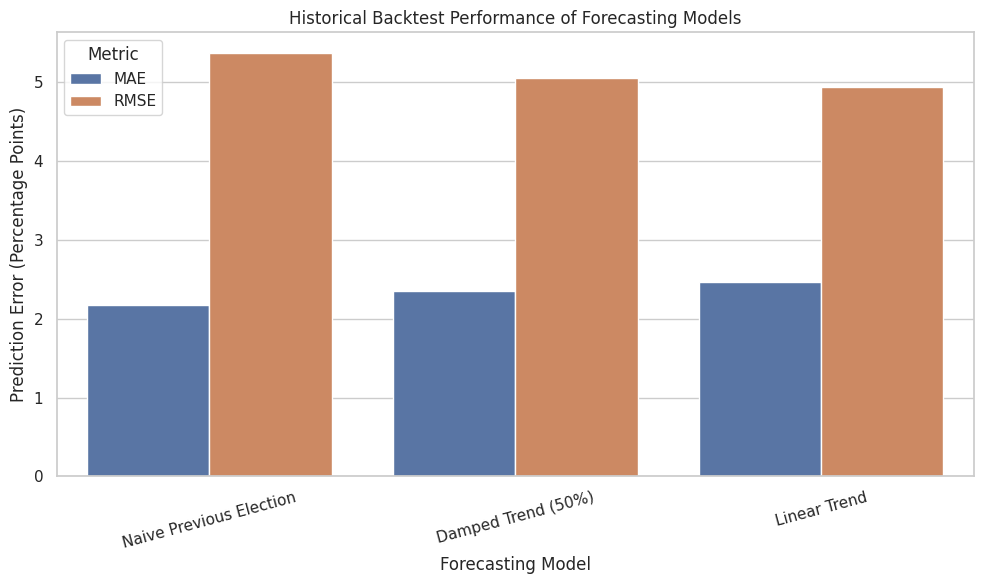

In [ ]:
comparison_long = model_comparison.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE"],
    var_name="Metric",
    value_name="Error"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Error",
    hue="Metric"
)

plt.title("Historical Backtest Performance of Forecasting Models")
plt.xlabel("Forecasting Model")
plt.ylabel("Prediction Error (Percentage Points)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### 13.6 Model Selection

Three forecasting approaches were evaluated using a historical 2021 backtest: a naive previous-election model, a 50% damped-trend model, and a linear-trend model.

The naive previous-election model achieved the lowest Mean Absolute Error (MAE) of approximately 2.177 percentage points. The damped-trend model produced an MAE of approximately 2.346 percentage points, while the linear-trend model produced an MAE of approximately 2.463 percentage points.

Although the linear-trend model achieved the lowest RMSE, the naive model produced the lowest average absolute prediction error. Large errors for some major parties also demonstrate that historical political trends can change substantially between elections.

Considering the limited number of historical election periods, the naive model is selected as the primary forecasting benchmark because it is simple, transparent and achieved the lowest MAE during historical backtesting.

The model assumes that a party's most recently observed vote share provides the best simple estimate of its next-election support. This is a strong assumption and therefore the resulting 2026 estimates must be interpreted with appropriate uncertainty and limitations.

## Step 14: Treatment of Parties With Shorter Historical Records

The primary backtesting analysis used parties with observations in all three historical elections to ensure a consistent comparison.

However, several politically relevant parties entered the available eThekwini election data after 2011. Excluding these parties from the 2026 forecast would result in an incomplete representation of the electoral landscape.

For parties without a complete three-election history, the most recent available PR vote share is therefore retained as a conservative baseline estimate. This approach avoids fabricating historical observations for years in which a party is not represented in the source data.

These estimates should be interpreted with greater caution because their historical trends cannot be evaluated over the same three-election period as the consistently observed parties.

In [ ]:
# STEP 14.1: Get most recent historical result for every party

latest_party_results = (
    party_year
    .sort_values(["PartyName", "Year"])
    .groupby("PartyName")
    .tail(1)
    .copy()
)

latest_party_results = latest_party_results[
    [
        "PartyName",
        "Year",
        "PartyVotes",
        "VoteShare"
    ]
].sort_values(
    "VoteShare",
    ascending=False
).reset_index(drop=True)

latest_party_results = latest_party_results.rename(
    columns={
        "Year": "LatestHistoricalYear",
        "VoteShare": "LatestVoteShare"
    }
)

display(latest_party_results.head(20))

,PartyName,LatestHistoricalYear,PartyVotes,LatestVoteShare
0,AFRICAN NATIONAL CONGRESS,2021,329307,42.505705
1,DEMOCRATIC ALLIANCE,2021,203980,26.328969
2,ECONOMIC FREEDOM FIGHTERS,2021,83699,10.803551
3,INKATHA FREEDOM PARTY,2021,57722,7.450538
4,ACTIONSA,2021,18201,2.349316
5,AFRICAN INDEPENDENT CONGRESS,2021,7809,1.007956
6,ACTIVE CITIZENS COALITION,2021,6239,0.805307
7,AFRICAN CHRISTIAN DEMOCRATIC PARTY,2021,5893,0.760646
8,ABANTU BATHO CONGRESS,2021,4998,0.645123
9,JUSTICE AND EMPLOYMENT PARTY,2021,4763,0.614790


In [ ]:
# STEP 14.2: Examine parties represented in the latest election

parties_2021 = (
    party_year[
        party_year["Year"] == 2021
    ]
    .copy()
    .sort_values("VoteShare", ascending=False)
)

print("=" * 70)
print("PARTIES AVAILABLE IN 2021")
print("=" * 70)

print("Number of parties:", len(parties_2021))

display(
    parties_2021[
        ["PartyName", "PartyVotes", "VoteShare"]
    ].head(20)
)

PARTIES AVAILABLE IN 2021
Number of parties: 50


,PartyName,PartyVotes,VoteShare
44,AFRICAN NATIONAL CONGRESS,329307,42.505705
45,DEMOCRATIC ALLIANCE,203980,26.328969
46,ECONOMIC FREEDOM FIGHTERS,83699,10.803551
47,INKATHA FREEDOM PARTY,57722,7.450538
48,ACTIONSA,18201,2.349316
49,AFRICAN INDEPENDENT CONGRESS,7809,1.007956
50,ACTIVE CITIZENS COALITION,6239,0.805307
51,AFRICAN CHRISTIAN DEMOCRATIC PARTY,5893,0.760646
52,ABANTU BATHO CONGRESS,4998,0.645123
53,JUSTICE AND EMPLOYMENT PARTY,4763,0.614790


## Step 15: Baseline Estimate for the 4 November 2026 Election

The selected naive forecasting approach is applied to produce a baseline estimate for the 4 November 2026 eThekwini local government election.

Under this model, each party's most recent available PR vote share is carried forward as its baseline 2026 estimate. For parties represented in the 2021 election data, the 2021 PR vote share therefore becomes the initial 2026 baseline estimate.

These values are model estimates only. They are not actual 2026 election results and should not be interpreted as known future outcomes.

The model does not directly account for campaign effects, coalition developments, candidate changes, voter turnout changes, demographic shifts, political events occurring after the historical data, or the entry and exit of political parties. These limitations are considered when interpreting the forecast.

In [ ]:
# STEP 15.1: Generate naive baseline estimates for 2026

forecast_2026 = parties_2021[
    [
        "PartyName",
        "VoteShare"
    ]
].copy()

forecast_2026 = forecast_2026.rename(
    columns={
        "VoteShare": "EstimatedVoteShare_2026"
    }
)

forecast_2026["ForecastYear"] = 2026

forecast_2026 = forecast_2026.sort_values(
    "EstimatedVoteShare_2026",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("BASELINE MODEL ESTIMATE - ETHEKWINI 2026")
print("=" * 70)

display(
    forecast_2026.head(15).round(2)
)

BASELINE MODEL ESTIMATE - ETHEKWINI 2026


,PartyName,EstimatedVoteShare_2026,ForecastYear
0,AFRICAN NATIONAL CONGRESS,42.51,2026
1,DEMOCRATIC ALLIANCE,26.33,2026
2,ECONOMIC FREEDOM FIGHTERS,10.80,2026
3,INKATHA FREEDOM PARTY,7.45,2026
4,ACTIONSA,2.35,2026
5,AFRICAN INDEPENDENT CONGRESS,1.01,2026
6,ACTIVE CITIZENS COALITION,0.81,2026
7,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.76,2026
8,ABANTU BATHO CONGRESS,0.65,2026
9,JUSTICE AND EMPLOYMENT PARTY,0.61,2026


In [ ]:
# STEP 15.2: Validate estimated vote-share total

forecast_total = (
    forecast_2026["EstimatedVoteShare_2026"].sum()
)

print(
    f"Total estimated 2026 vote share: "
    f"{forecast_total:.2f}%"
)

Total estimated 2026 vote share: 100.00%


## Step 16: Forecast Uncertainty

Election forecasts are inherently uncertain. The point estimates produced by the model should therefore not be interpreted as exact predictions of the 4 November 2026 election results.

Historical backtesting showed that the selected naive model had a Mean Absolute Error (MAE) of approximately 2.177 percentage points when predicting the 2021 election from the previous election.

This historical MAE is used as a simple empirical uncertainty margin around the baseline 2026 estimates. The resulting ranges are descriptive forecast uncertainty bands rather than formal statistical confidence intervals.

Lower bounds are restricted to 0% and upper bounds to 100%. Political developments, turnout changes, new parties, party withdrawals, campaign effects and other events could still produce outcomes outside these ranges.

In [ ]:
# STEP 16.1: Add empirical uncertainty ranges

uncertainty_margin = naive_mae

forecast_2026["LowerBound"] = (
    forecast_2026["EstimatedVoteShare_2026"]
    - uncertainty_margin
).clip(lower=0)

forecast_2026["UpperBound"] = (
    forecast_2026["EstimatedVoteShare_2026"]
    + uncertainty_margin
).clip(upper=100)

print("=" * 70)
print("2026 FORECAST WITH EMPIRICAL UNCERTAINTY")
print("=" * 70)

forecast_display = forecast_2026[
    [
        "PartyName",
        "EstimatedVoteShare_2026",
        "LowerBound",
        "UpperBound"
    ]
].copy()

display(forecast_display.head(15).round(2))

2026 FORECAST WITH EMPIRICAL UNCERTAINTY


,PartyName,EstimatedVoteShare_2026,LowerBound,UpperBound
0,AFRICAN NATIONAL CONGRESS,42.51,40.33,44.68
1,DEMOCRATIC ALLIANCE,26.33,24.15,28.51
2,ECONOMIC FREEDOM FIGHTERS,10.80,8.63,12.98
3,INKATHA FREEDOM PARTY,7.45,5.27,9.63
4,ACTIONSA,2.35,0.17,4.53
5,AFRICAN INDEPENDENT CONGRESS,1.01,0.00,3.18
6,ACTIVE CITIZENS COALITION,0.81,0.00,2.98
7,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.76,0.00,2.94
8,ABANTU BATHO CONGRESS,0.65,0.00,2.82
9,JUSTICE AND EMPLOYMENT PARTY,0.61,0.00,2.79


### 16.2 Historical Data Coverage

Not all political parties have the same amount of historical information available. A data-coverage indicator is therefore included with the forecast.

Parties appearing in all three historical elections have greater historical coverage, while parties appearing in only one election have substantially less information available for assessing their long-term electoral behaviour.

This indicator does not measure the probability that a forecast is correct. It communicates the amount of historical evidence available for each party.

In [ ]:
# STEP 16.2: Add historical election coverage

history_count_df = (
    party_year
    .groupby("PartyName")["Year"]
    .nunique()
    .reset_index(name="HistoricalElections")
)

forecast_2026 = forecast_2026.merge(
    history_count_df,
    on="PartyName",
    how="left"
)

def coverage_label(count):
    if count == 3:
        return "Higher historical coverage"
    elif count == 2:
        return "Moderate historical coverage"
    else:
        return "Limited historical coverage"

forecast_2026["DataCoverage"] = (
    forecast_2026["HistoricalElections"]
    .apply(coverage_label)
)

display(
    forecast_2026[
        [
            "PartyName",
            "EstimatedVoteShare_2026",
            "LowerBound",
            "UpperBound",
            "HistoricalElections",
            "DataCoverage"
        ]
    ].head(15).round(2)
)

,PartyName,EstimatedVoteShare_2026,LowerBound,UpperBound,HistoricalElections,DataCoverage
0,AFRICAN NATIONAL CONGRESS,42.51,40.33,44.68,3,Higher historical coverage
1,DEMOCRATIC ALLIANCE,26.33,24.15,28.51,3,Higher historical coverage
2,ECONOMIC FREEDOM FIGHTERS,10.80,8.63,12.98,2,Moderate historical coverage
3,INKATHA FREEDOM PARTY,7.45,5.27,9.63,3,Higher historical coverage
4,ACTIONSA,2.35,0.17,4.53,1,Limited historical coverage
5,AFRICAN INDEPENDENT CONGRESS,1.01,0.00,3.18,2,Moderate historical coverage
6,ACTIVE CITIZENS COALITION,0.81,0.00,2.98,1,Limited historical coverage
7,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.76,0.00,2.94,3,Higher historical coverage
8,ABANTU BATHO CONGRESS,0.65,0.00,2.82,1,Limited historical coverage
9,JUSTICE AND EMPLOYMENT PARTY,0.61,0.00,2.79,1,Limited historical coverage


## Step 17: Visualisation of the 2026 Election Model Estimate

The leading baseline estimates are visualised to communicate the projected distribution of party support in eThekwini for the 4 November 2026 local government election.

Only the leading parties are displayed to maintain readability. The values represent model estimates and must not be interpreted as actual election results.

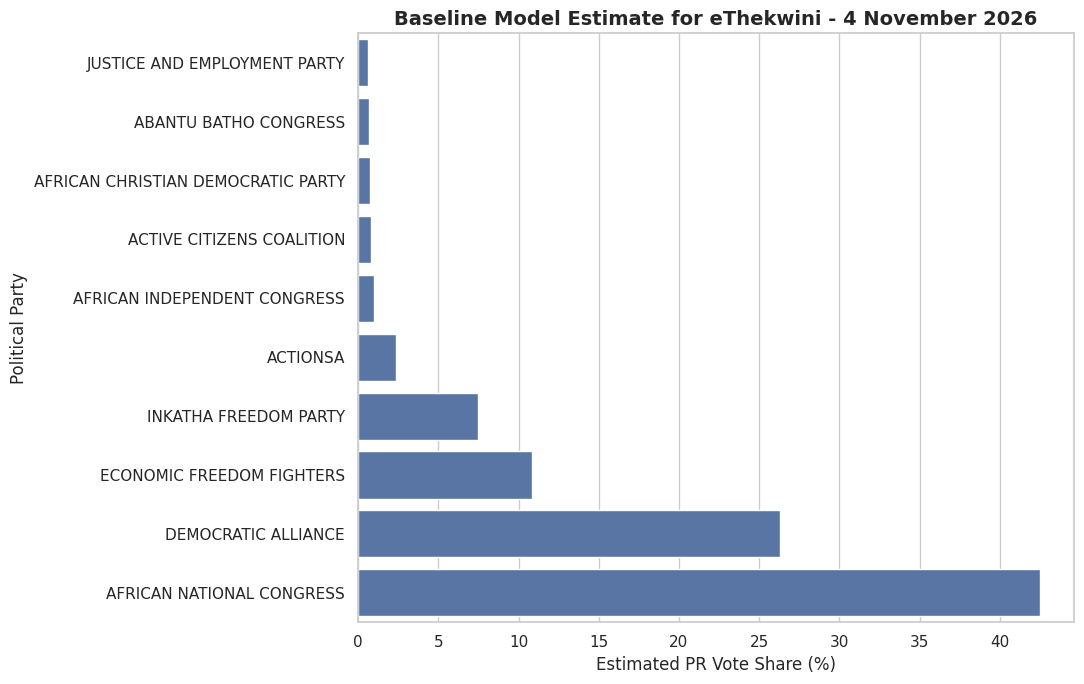

In [ ]:
# STEP 17.1: Visualise top 10 estimated party vote shares

top10_forecast = (
    forecast_2026
    .nlargest(10, "EstimatedVoteShare_2026")
    .sort_values("EstimatedVoteShare_2026")
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top10_forecast,
    x="EstimatedVoteShare_2026",
    y="PartyName"
)

plt.title(
    "Baseline Model Estimate for eThekwini - 4 November 2026",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Estimated PR Vote Share (%)")
plt.ylabel("Political Party")

plt.tight_layout()
plt.show()

### 17.2 Comparison With the 2021 Historical Results

The 2026 baseline estimates are compared with the actual 2021 PR vote shares.

Because the selected naive model carries the most recent observed vote share forward, the baseline 2026 point estimates are identical to the corresponding 2021 values. The purpose of this model is therefore to provide a conservative benchmark rather than to claim that party support will remain unchanged.

The comparison also highlights an important limitation of the model: it cannot independently anticipate political shifts occurring after the 2021 election.

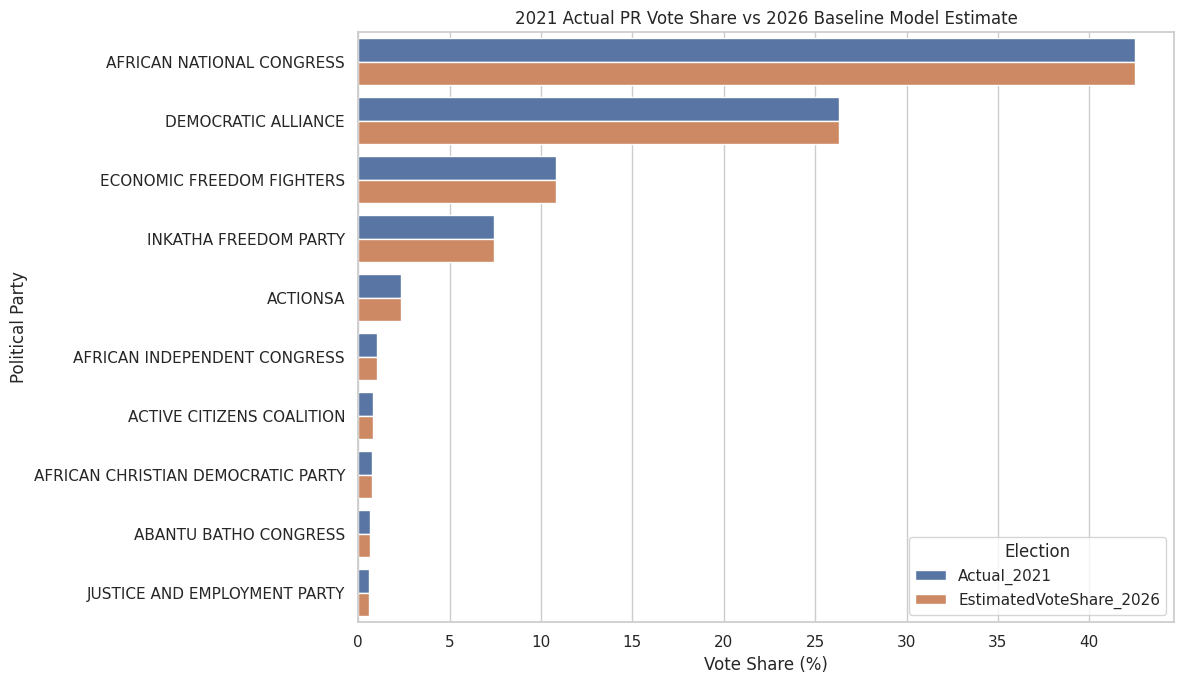

In [ ]:
# STEP 17.2: Compare actual 2021 results with baseline 2026 estimates

comparison_2021_2026 = forecast_2026.merge(
    parties_2021[
        ["PartyName", "VoteShare"]
    ],
    on="PartyName",
    how="left"
)

comparison_2021_2026 = comparison_2021_2026.rename(
    columns={"VoteShare": "Actual_2021"}
)

top_parties_comparison = (
    comparison_2021_2026
    .nlargest(10, "EstimatedVoteShare_2026")
)

comparison_long = top_parties_comparison.melt(
    id_vars="PartyName",
    value_vars=[
        "Actual_2021",
        "EstimatedVoteShare_2026"
    ],
    var_name="Election",
    value_name="VoteShare"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=comparison_long,
    x="VoteShare",
    y="PartyName",
    hue="Election"
)

plt.title(
    "2021 Actual PR Vote Share vs 2026 Baseline Model Estimate"
)

plt.xlabel("Vote Share (%)")
plt.ylabel("Political Party")

plt.tight_layout()
plt.show()

## Step 18: Interpretation of the 2026 Baseline Forecast

The baseline model estimates the distribution of PR party support in eThekwini for the 4 November 2026 local government election using the most recent historical vote share available for each party.

Under this conservative baseline, the African National Congress (ANC) remains the largest party with an estimated vote share of approximately 42.51%, followed by the Democratic Alliance (DA) at approximately 26.33%. The Economic Freedom Fighters (EFF) have a baseline estimate of approximately 10.80%, while the Inkatha Freedom Party (IFP) is estimated at approximately 7.45%. ActionSA follows at approximately 2.35%.

The model does not estimate any party above the 50% threshold. Under the baseline assumptions, this indicates that no single party is projected to obtain an outright majority of the PR vote. However, this should not be interpreted as a prediction of council control or a specific coalition outcome because council-seat allocation and coalition formation require additional information and analysis.

Historical backtesting produced an MAE of approximately 2.177 percentage points. This error is used to construct descriptive uncertainty bands around the baseline estimates. For example, the ANC baseline estimate of 42.51% has an empirical range of approximately 40.33% to 44.68%.

The amount of historical evidence differs between parties. The ANC, DA and IFP have observations across all three historical elections used in the analysis, while the EFF has two observations and ActionSA has only one. Forecasts for parties with shorter historical records therefore require greater caution.

Most importantly, these values are model estimates rather than actual 2026 election results. The baseline model assumes that the most recent observed party support remains unchanged and cannot independently anticipate political developments occurring between the 2021 and 2026 elections.

## Step 19: Model Assumptions and Limitations

The forecasting results must be interpreted within the limitations of the available data and modelling approach.

### Assumptions

1. The most recent historical PR vote share provides a reasonable conservative baseline for future party support.
2. Historical IEC election results are assumed to have been correctly captured and processed.
3. PR ballot results are used consistently because comparable PR records are available across 2011, 2016 and 2021 in the datasets used.
4. Historical voting patterns contain some information relevant to subsequent elections.

### Limitations

The analysis contains only three historical municipal election periods: 2011, 2016 and 2021. This severely limits the amount of temporal information available for forecasting and makes complex time-series modelling unreliable.

Political parties also have unequal historical coverage. Some parties have observations across all three elections, while newer parties have only one or two historical observations.

The selected naive baseline assumes that 2021 party vote shares remain unchanged in 2026. It therefore cannot independently capture changes caused by campaigns, leadership changes, coalitions, political events, voter sentiment, demographic change, turnout variation, party entry or withdrawal, or other developments occurring after the historical election.

The uncertainty ranges are based on historical MAE and are descriptive empirical error bands. They are not formal statistical confidence intervals.

The forecast therefore represents a data-driven baseline scenario rather than a guaranteed prediction of the 2026 election outcome.

## Step 20: Ethical and Responsible Use of the Forecast

Election forecasting can influence public perceptions and must therefore be communicated responsibly.

Historical observations and future model estimates are clearly separated throughout this analysis. The 2026 estimates are not presented as known election results.

The model does not attempt to infer individual voters' political preferences or use sensitive personal characteristics. Analysis is conducted using aggregated election information.

Model uncertainty and data limitations are disclosed to reduce the risk of presenting the forecast with unjustified precision. Parties with limited historical data are also identified so that their estimates are not interpreted as having the same historical support as parties with longer records.

The results should therefore be used as an analytical scenario for understanding historical electoral patterns rather than as a definitive statement about how individuals will vote or which political party will govern eThekwini after the 2026 election.

## Step 21: Machine-Learning Dataset Development

The previous forecasting stage established a simple and transparent baseline using aggregated party-level election results.

To investigate whether a supervised machine-learning model can improve on this baseline, a more detailed dataset is now constructed using voting-district-level PR election results.

Each observation represents the performance of a political party within a voting district during a particular election. This provides substantially more observations than the municipality-level party dataset and allows the model to learn patterns associated with previous local party support, registered voter numbers and historical election performance.

A time-aware modelling strategy is used. Historical elections are used to construct features for subsequent elections rather than randomly mixing observations from different election years. This reduces the risk of data leakage and better represents the real forecasting problem.

In [ ]:
# STEP 21.1: Recreate combined historical dataset if necessary

import pandas as pd
import numpy as np

election_all = pd.concat(
    [
        election_2011_detail,
        election_2016_detail,
        election_2021_detail
    ],
    ignore_index=True
)

print("Combined dataset shape:", election_all.shape)
print("Years:", sorted(election_all["Year"].unique()))

Combined dataset shape: (98073, 12)
Years: [np.int64(2011), np.int64(2016), np.int64(2021)]


In [ ]:
# STEP 21.1: Extract PR election records

ml_pr = election_all[
    election_all["BallotType"] == "PR"
].copy()

print("=" * 70)
print("PR DATASET FOR MACHINE LEARNING")
print("=" * 70)

print("Shape:", ml_pr.shape)

print("\nRows by election year:")
print(
    ml_pr["Year"]
    .value_counts()
    .sort_index()
)

print("\nUnique parties by year:")
print(
    ml_pr.groupby("Year")["PartyName"].nunique()
)

print("\nUnique voting districts by year:")
print(
    ml_pr.groupby("Year")["VotingDistrict"].nunique()
)

PR DATASET FOR MACHINE LEARNING
Shape: (80749, 12)

Rows by election year:
Year
2011    13617
2016    23382
2021    43750
Name: count, dtype: int64

Unique parties by year:
Year
2011    17
2016    27
2021    50
Name: PartyName, dtype: int64

Unique voting districts by year:
Year
2011    801
2016    866
2021    875
Name: VotingDistrict, dtype: int64


In [ ]:
# STEP 21.2: Aggregate PR votes by voting district and party

district_party = (
    ml_pr
    .groupby(
        ["Year", "VotingDistrict", "PartyName"],
        as_index=False
    )
    .agg(
        PartyVotes=("TotalValidVotes", "sum"),
        RegisteredVoters=("RegisteredVoters", "max")
    )
)

print("=" * 70)
print("VOTING-DISTRICT PARTY DATASET")
print("=" * 70)

print("Shape:", district_party.shape)

print("\nRows by election year:")
print(
    district_party["Year"]
    .value_counts()
    .sort_index()
)

print("\nFirst 10 rows:")
display(district_party.head(10))

VOTING-DISTRICT PARTY DATASET
Shape: (80749, 5)

Rows by election year:
Year
2011    13617
2016    23382
2021    43750
Name: count, dtype: int64

First 10 rows:


,Year,VotingDistrict,PartyName,PartyVotes,RegisteredVoters
0,2011,43350016,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1,3724
1,2011,43350016,AFRICAN CHRISTIAN DEMOCRATIC PARTY,23,3724
2,2011,43350016,AFRICAN NATIONAL CONGRESS,201,3724
3,2011,43350016,AFRICAN PEOPLE'S CONVENTION,1,3724
4,2011,43350016,AZANIAN PEOPLE'S ORGANISATION,0,3724
5,2011,43350016,BLACK CONSCIOUSNESS PARTY,1,3724
6,2011,43350016,CONGRESS OF THE PEOPLE,5,3724
7,2011,43350016,DEMOCRATIC ALLIANCE,1982,3724
8,2011,43350016,INKATHA FREEDOM PARTY,4,3724
9,2011,43350016,MINORITY FRONT,28,3724


In [ ]:
# STEP 21.3: Calculate total PR votes and local vote share

district_party["DistrictTotalVotes"] = (
    district_party
    .groupby(
        ["Year", "VotingDistrict"]
    )["PartyVotes"]
    .transform("sum")
)

district_party["LocalVoteShare"] = np.where(
    district_party["DistrictTotalVotes"] > 0,
    (
        district_party["PartyVotes"]
        / district_party["DistrictTotalVotes"]
    ) * 100,
    0
)

print("=" * 70)
print("LOCAL PARTY VOTE SHARE")
print("=" * 70)

display(
    district_party[
        [
            "Year",
            "VotingDistrict",
            "PartyName",
            "RegisteredVoters",
            "PartyVotes",
            "DistrictTotalVotes",
            "LocalVoteShare"
        ]
    ].head(15)
)

LOCAL PARTY VOTE SHARE


,Year,VotingDistrict,PartyName,RegisteredVoters,PartyVotes,DistrictTotalVotes,LocalVoteShare
0,2011,43350016,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,3724,1,2255,0.044346
1,2011,43350016,AFRICAN CHRISTIAN DEMOCRATIC PARTY,3724,23,2255,1.019956
2,2011,43350016,AFRICAN NATIONAL CONGRESS,3724,201,2255,8.913525
3,2011,43350016,AFRICAN PEOPLE'S CONVENTION,3724,1,2255,0.044346
4,2011,43350016,AZANIAN PEOPLE'S ORGANISATION,3724,0,2255,0.000000
5,2011,43350016,BLACK CONSCIOUSNESS PARTY,3724,1,2255,0.044346
6,2011,43350016,CONGRESS OF THE PEOPLE,3724,5,2255,0.221729
7,2011,43350016,DEMOCRATIC ALLIANCE,3724,1982,2255,87.893570
8,2011,43350016,INKATHA FREEDOM PARTY,3724,4,2255,0.177384
9,2011,43350016,MINORITY FRONT,3724,28,2255,1.241685


In [ ]:
# STEP 21.4: Validate local vote-share calculations

vote_share_check = (
    district_party
    .groupby(
        ["Year", "VotingDistrict"]
    )["LocalVoteShare"]
    .sum()
)

print("=" * 70)
print("LOCAL VOTE-SHARE VALIDATION")
print("=" * 70)

print(f"Minimum total: {vote_share_check.min():.6f}%")
print(f"Maximum total: {vote_share_check.max():.6f}%")
print(f"Average total: {vote_share_check.mean():.6f}%")

print(
    "Number of district-year groups:",
    len(vote_share_check)
)

print(
    "Groups approximately equal to 100%:",
    np.isclose(vote_share_check, 100).sum()
)

LOCAL VOTE-SHARE VALIDATION
Minimum total: 100.000000%
Maximum total: 100.000000%
Average total: 100.000000%
Number of district-year groups: 2542
Groups approximately equal to 100%: 2542


### 21.5 Voting-District Continuity Across Elections

The number of voting districts differs between the 2011, 2016 and 2021 elections. Therefore, voting-district identifiers cannot automatically be assumed to have complete historical coverage.

Voting-district identifiers are compared across consecutive elections to determine how many can be matched before previous-election features are constructed.

This step helps prevent invalid historical matching and reduces the risk of introducing misleading observations into the machine-learning dataset.

In [ ]:
# STEP 21.5: Examine voting-district continuity

districts_by_year = {
    year: set(
        district_party.loc[
            district_party["Year"] == year,
            "VotingDistrict"
        ].unique()
    )
    for year in [2011, 2016, 2021]
}

common_2011_2016 = (
    districts_by_year[2011]
    & districts_by_year[2016]
)

common_2016_2021 = (
    districts_by_year[2016]
    & districts_by_year[2021]
)

common_all_years = (
    districts_by_year[2011]
    & districts_by_year[2016]
    & districts_by_year[2021]
)

print("=" * 70)
print("VOTING-DISTRICT CONTINUITY")
print("=" * 70)

for year in [2011, 2016, 2021]:
    print(
        f"{year}: "
        f"{len(districts_by_year[year])} unique voting districts"
    )

print("\nMatched voting districts:")
print("2011 -> 2016:", len(common_2011_2016))
print("2016 -> 2021:", len(common_2016_2021))
print("Present in all three:", len(common_all_years))

VOTING-DISTRICT CONTINUITY
2011: 801 unique voting districts
2016: 866 unique voting districts
2021: 875 unique voting districts

Matched voting districts:
2011 -> 2016: 799
2016 -> 2021: 863
Present in all three: 797


In [ ]:
# STEP 21.6: Check party + voting-district historical matches

party_district_sets = {}

for year in [2011, 2016, 2021]:
    year_data = district_party[
        district_party["Year"] == year
    ]

    party_district_sets[year] = set(
        zip(
            year_data["VotingDistrict"],
            year_data["PartyName"]
        )
    )

matches_11_16 = (
    party_district_sets[2011]
    & party_district_sets[2016]
)

matches_16_21 = (
    party_district_sets[2016]
    & party_district_sets[2021]
)

matches_all = (
    party_district_sets[2011]
    & party_district_sets[2016]
    & party_district_sets[2021]
)

print("=" * 70)
print("PARTY + VOTING-DISTRICT HISTORICAL MATCHES")
print("=" * 70)

print(
    "Matched 2011 -> 2016 combinations:",
    len(matches_11_16)
)

print(
    "Matched 2016 -> 2021 combinations:",
    len(matches_16_21)
)

print(
    "Present in all three elections:",
    len(matches_all)
)

PARTY + VOTING-DISTRICT HISTORICAL MATCHES
Matched 2011 -> 2016 combinations: 8789
Matched 2016 -> 2021 combinations: 18123
Present in all three elections: 7970


## Step 22: Construction of the Supervised Machine-Learning Dataset

Voting-district continuity analysis identified strong overlap between historical elections. A total of 799 voting districts could be matched between 2011 and 2016, while 863 could be matched between 2016 and 2021. In addition, 797 voting districts were present in all three historical elections.

At the party-and-voting-district level, 8,789 combinations were matched between 2011 and 2016 and 18,123 combinations between 2016 and 2021.

These matched observations make it possible to construct a supervised machine-learning dataset. Information from a previous election is used as predictor information, while the party's local vote share in the following election becomes the prediction target.

This chronological structure ensures that future election information is not used to predict the past and supports time-aware model evaluation.

In [ ]:
# STEP 22.1: Create 2011 -> 2016 historical training pairs

data_2011 = district_party[
    district_party["Year"] == 2011
][
    [
        "VotingDistrict",
        "PartyName",
        "RegisteredVoters",
        "PartyVotes",
        "DistrictTotalVotes",
        "LocalVoteShare"
    ]
].copy()

data_2016 = district_party[
    district_party["Year"] == 2016
][
    [
        "VotingDistrict",
        "PartyName",
        "RegisteredVoters",
        "PartyVotes",
        "DistrictTotalVotes",
        "LocalVoteShare"
    ]
].copy()

pairs_11_16 = data_2011.merge(
    data_2016,
    on=["VotingDistrict", "PartyName"],
    how="inner",
    suffixes=("_Previous", "_Target")
)

pairs_11_16["PreviousYear"] = 2011
pairs_11_16["TargetYear"] = 2016

print("=" * 70)
print("2011 -> 2016 TRAINING PAIRS")
print("=" * 70)

print("Shape:", pairs_11_16.shape)

display(pairs_11_16.head())

2011 -> 2016 TRAINING PAIRS
Shape: (8789, 12)


,VotingDistrict,PartyName,RegisteredVoters_Previous,PartyVotes_Previous,DistrictTotalVotes_Previous,LocalVoteShare_Previous,RegisteredVoters_Target,PartyVotes_Target,DistrictTotalVotes_Target,LocalVoteShare_Target,PreviousYear,TargetYear
0,43350016,AFRICAN CHRISTIAN DEMOCRATIC PARTY,3724,23,2255,1.019956,5180,27,2801,0.963941,2011,2016
1,43350016,AFRICAN NATIONAL CONGRESS,3724,201,2255,8.913525,5180,252,2801,8.996787,2011,2016
2,43350016,AFRICAN PEOPLE'S CONVENTION,3724,1,2255,0.044346,5180,0,2801,0.000000,2011,2016
3,43350016,AZANIAN PEOPLE'S ORGANISATION,3724,0,2255,0.000000,5180,1,2801,0.035702,2011,2016
4,43350016,CONGRESS OF THE PEOPLE,3724,5,2255,0.221729,5180,3,2801,0.107105,2011,2016


In [ ]:
# STEP 22.2: Create 2016 -> 2021 historical pairs

data_2016 = district_party[
    district_party["Year"] == 2016
][
    [
        "VotingDistrict",
        "PartyName",
        "RegisteredVoters",
        "PartyVotes",
        "DistrictTotalVotes",
        "LocalVoteShare"
    ]
].copy()

data_2021 = district_party[
    district_party["Year"] == 2021
][
    [
        "VotingDistrict",
        "PartyName",
        "RegisteredVoters",
        "PartyVotes",
        "DistrictTotalVotes",
        "LocalVoteShare"
    ]
].copy()

pairs_16_21 = data_2016.merge(
    data_2021,
    on=["VotingDistrict", "PartyName"],
    how="inner",
    suffixes=("_Previous", "_Target")
)

pairs_16_21["PreviousYear"] = 2016
pairs_16_21["TargetYear"] = 2021

print("=" * 70)
print("2016 -> 2021 HISTORICAL PAIRS")
print("=" * 70)

print("Shape:", pairs_16_21.shape)

display(pairs_16_21.head())

2016 -> 2021 HISTORICAL PAIRS
Shape: (18123, 12)


,VotingDistrict,PartyName,RegisteredVoters_Previous,PartyVotes_Previous,DistrictTotalVotes_Previous,LocalVoteShare_Previous,RegisteredVoters_Target,PartyVotes_Target,DistrictTotalVotes_Target,LocalVoteShare_Target,PreviousYear,TargetYear
0,43350016,ACADEMIC CONGRESS UNION,5180,0,2801,0.000000,4291,1,2222,0.045005,2016,2021
1,43350016,AFRICAN CHRISTIAN DEMOCRATIC PARTY,5180,27,2801,0.963941,4291,6,2222,0.270027,2016,2021
2,43350016,AFRICAN INDEPENDENT CONGRESS,5180,2,2801,0.071403,4291,1,2222,0.045005,2016,2021
3,43350016,AFRICAN MANTUNGWA COMMUNITY,5180,0,2801,0.000000,4291,0,2222,0.000000,2016,2021
4,43350016,AFRICAN NATIONAL CONGRESS,5180,252,2801,8.996787,4291,103,2222,4.635464,2016,2021


### 22.3 Machine-Learning Features and Target

Predictor variables are constructed using information associated with the previous election.

The main historical predictor is `PreviousLocalVoteShare`, representing the party's support within the same voting district during the previous election. Additional predictors describe previous party votes, registered voter numbers, changes in the registered electorate, and political party identity.

The target variable is `TargetLocalVoteShare`, representing the party's actual local vote share in the subsequent election.

Only information available before or at the target election is used to construct predictors, helping to prevent target leakage.

In [ ]:
# STEP 22.3: Create ML features

def prepare_ml_pairs(df):

    ml = pd.DataFrame()

    ml["VotingDistrict"] = df["VotingDistrict"]
    ml["PartyName"] = df["PartyName"]

    ml["PreviousYear"] = df["PreviousYear"]
    ml["TargetYear"] = df["TargetYear"]

    ml["PreviousLocalVoteShare"] = (
        df["LocalVoteShare_Previous"]
    )

    ml["PreviousPartyVotes"] = (
        df["PartyVotes_Previous"]
    )

    ml["PreviousRegisteredVoters"] = (
        df["RegisteredVoters_Previous"]
    )

    ml["TargetRegisteredVoters"] = (
        df["RegisteredVoters_Target"]
    )

    ml["RegisteredVoterChange"] = (
        df["RegisteredVoters_Target"]
        - df["RegisteredVoters_Previous"]
    )

    ml["TargetLocalVoteShare"] = (
        df["LocalVoteShare_Target"]
    )

    return ml

In [ ]:
ml_11_16 = prepare_ml_pairs(pairs_11_16)
ml_16_21 = prepare_ml_pairs(pairs_16_21)

print("2011 -> 2016 ML observations:", len(ml_11_16))
print("2016 -> 2021 ML observations:", len(ml_16_21))

display(ml_11_16.head())

2011 -> 2016 ML observations: 8789
2016 -> 2021 ML observations: 18123


,VotingDistrict,PartyName,PreviousYear,TargetYear,PreviousLocalVoteShare,PreviousPartyVotes,PreviousRegisteredVoters,TargetRegisteredVoters,RegisteredVoterChange,TargetLocalVoteShare
0,43350016,AFRICAN CHRISTIAN DEMOCRATIC PARTY,2011,2016,1.019956,23,3724,5180,1456,0.963941
1,43350016,AFRICAN NATIONAL CONGRESS,2011,2016,8.913525,201,3724,5180,1456,8.996787
2,43350016,AFRICAN PEOPLE'S CONVENTION,2011,2016,0.044346,1,3724,5180,1456,0.000000
3,43350016,AZANIAN PEOPLE'S ORGANISATION,2011,2016,0.000000,0,3724,5180,1456,0.035702
4,43350016,CONGRESS OF THE PEOPLE,2011,2016,0.221729,5,3724,5180,1456,0.107105


In [ ]:
# STEP 22.4: Validate ML datasets

print("=" * 70)
print("MACHINE-LEARNING DATA VALIDATION")
print("=" * 70)

print("\n2011 -> 2016")
print("Shape:", ml_11_16.shape)
print("Missing values:")
print(ml_11_16.isnull().sum())

print("\n2016 -> 2021")
print("Shape:", ml_16_21.shape)
print("Missing values:")
print(ml_16_21.isnull().sum())

print("\nTarget statistics - 2016:")
print(
    ml_11_16["TargetLocalVoteShare"].describe()
)

print("\nTarget statistics - 2021:")
print(
    ml_16_21["TargetLocalVoteShare"].describe()
)

MACHINE-LEARNING DATA VALIDATION

2011 -> 2016
Shape: (8789, 10)
Missing values:
VotingDistrict              0
PartyName                   0
PreviousYear                0
TargetYear                  0
PreviousLocalVoteShare      0
PreviousPartyVotes          0
PreviousRegisteredVoters    0
TargetRegisteredVoters      0
RegisteredVoterChange       0
TargetLocalVoteShare        0
dtype: int64

2016 -> 2021
Shape: (18123, 10)
Missing values:
VotingDistrict              0
PartyName                   0
PreviousYear                0
TargetYear                  0
PreviousLocalVoteShare      0
PreviousPartyVotes          0
PreviousRegisteredVoters    0
TargetRegisteredVoters      0
RegisteredVoterChange       0
TargetLocalVoteShare        0
dtype: int64

Target statistics - 2016:
count    8789.000000
mean        8.454043
std        22.732334
min         0.000000
25%         0.000000
50%         0.192555
75%         1.568627
max        98.087954
Name: TargetLocalVoteShare, dtype: float64

Targe

### 22.5 Time-Based Training and Testing Strategy

The machine-learning model is evaluated using a chronological train-test design rather than a random split.

The 2011 election is used to construct predictors for the 2016 outcomes, forming the training dataset. The model is then evaluated on the 2016-to-2021 transition.

Therefore:

- Training observations: 2011 → 2016
- Testing observations: 2016 → 2021
- Prediction target: subsequent-election local party vote share

This design more closely represents the real forecasting problem because the model is trained using earlier information and evaluated on a later election that was not used during training.

In [ ]:
# STEP 22.5: Define chronological train and test datasets

train_data = ml_11_16.copy()
test_data = ml_16_21.copy()

print("=" * 70)
print("TIME-BASED TRAIN / TEST SPLIT")
print("=" * 70)

print(
    f"Training observations: {len(train_data):,}"
)

print(
    f"Testing observations:  {len(test_data):,}"
)

print("\nTraining transition:")
print("2011 -> 2016")

print("\nTesting transition:")
print("2016 -> 2021")

TIME-BASED TRAIN / TEST SPLIT
Training observations: 8,789
Testing observations:  18,123

Training transition:
2011 -> 2016

Testing transition:
2016 -> 2021


## Step 23: Supervised Machine-Learning Model Development

Supervised regression models are now trained to predict a political party's local PR vote share in the subsequent municipal election.

The models are trained using the 2011-to-2016 historical transition and evaluated using the later 2016-to-2021 transition. This chronological evaluation prevents future election outcomes from being included in the training data.

Three approaches will be compared:

1. A naive district-level baseline that assumes local party support remains unchanged from the previous election.
2. Linear Regression as an interpretable statistical machine-learning model.
3. Random Forest Regression as a non-linear machine-learning model capable of learning more complex relationships.

Model performance will be evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

In [ ]:
# STEP 23.1: District-level naive baseline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

y_test = test_data["TargetLocalVoteShare"]

naive_predictions = test_data[
    "PreviousLocalVoteShare"
].values

naive_mae_district = mean_absolute_error(
    y_test,
    naive_predictions
)

naive_rmse_district = np.sqrt(
    mean_squared_error(
        y_test,
        naive_predictions
    )
)

naive_r2_district = r2_score(
    y_test,
    naive_predictions
)

print("=" * 70)
print("DISTRICT-LEVEL NAIVE BASELINE")
print("=" * 70)

print(
    f"MAE:  {naive_mae_district:.3f} percentage points"
)

print(
    f"RMSE: {naive_rmse_district:.3f} percentage points"
)

print(
    f"R²:   {naive_r2_district:.3f}"
)

DISTRICT-LEVEL NAIVE BASELINE
MAE:  1.757 percentage points
RMSE: 5.210 percentage points
R²:   0.861


### 23.2 Predictor Selection

The machine-learning models use previous-election information to predict subsequent local party vote share.

The predictors include previous local vote share, previous party vote count, previous registered voter population, change in registered voters, and political party identity.

`VotingDistrict` is retained for identification and later analysis but is not treated as a numerical predictor because its identifier does not represent a continuous quantitative measurement.

Political party is treated as a categorical variable and encoded before model training.

In [ ]:
# STEP 23.2: Define features and target

numeric_features = [
    "PreviousLocalVoteShare",
    "PreviousPartyVotes",
    "PreviousRegisteredVoters",
    "RegisteredVoterChange"
]

categorical_features = [
    "PartyName"
]

feature_columns = (
    numeric_features
    + categorical_features
)

X_train = train_data[feature_columns].copy()
y_train = train_data["TargetLocalVoteShare"].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data["TargetLocalVoteShare"].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nFeatures:")
print(feature_columns)

X_train shape: (8789, 5)
X_test shape: (18123, 5)

Features:
['PreviousLocalVoteShare', 'PreviousPartyVotes', 'PreviousRegisteredVoters', 'RegisteredVoterChange', 'PartyName']


### 23.3 Feature Preprocessing

Numerical predictors are passed directly to the regression models, while political party identity is transformed using one-hot encoding.

One-hot encoding allows party identity to be represented without incorrectly implying that political parties have a numerical order.

Unknown categories are ignored during testing. This is important because the set of political parties may differ between election periods.

In [ ]:
# STEP 23.3: Create preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "party",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Step 23: Machine-Learning Model Training and Evaluation

Three predictive approaches are evaluated using the chronological train-test structure.

The models are:

1. **Naive Baseline** – assumes that a party's local vote share remains unchanged from the previous election.
2. **Linear Regression** – provides an interpretable supervised regression benchmark.
3. **Random Forest Regression** – captures potentially non-linear relationships between historical electoral characteristics and subsequent party support.

The models are trained using the 2011-to-2016 transition and evaluated on the unseen 2016-to-2021 transition.

Predictors include previous local vote share, previous party votes, previous registered voters, change in registered voters, and political party identity. Party identity is transformed using one-hot encoding.

Performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R². Lower MAE and RMSE values indicate better predictive accuracy, while higher R² values indicate stronger explanatory performance.

TRAINING / TESTING DATA
Training observations: 8,789
Testing observations:  18,123

MODEL PERFORMANCE


,Model,MAE,RMSE,R2
0,Naive Baseline,1.757,5.210,0.861
1,Random Forest,1.922,5.613,0.839
2,Linear Regression,2.013,5.129,0.865



BEST MODEL BASED ON MAE
Best model: Naive Baseline
MAE: 1.757 percentage points


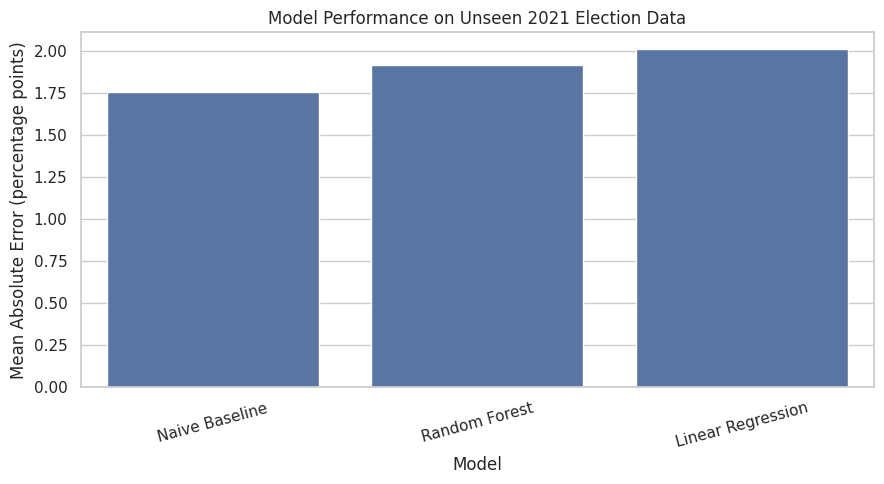

In [ ]:
# ============================================================
# STEP 23: TRAIN AND COMPARE MACHINE-LEARNING MODELS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. SELECT FEATURES AND TARGET
# ------------------------------------------------------------

numeric_features = [
    "PreviousLocalVoteShare",
    "PreviousPartyVotes",
    "PreviousRegisteredVoters",
    "RegisteredVoterChange"
]

categorical_features = [
    "PartyName"
]

feature_columns = numeric_features + categorical_features

# Chronological split
# Train: 2011 -> 2016
# Test:  2016 -> 2021

X_train = train_data[feature_columns].copy()
y_train = train_data["TargetLocalVoteShare"].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data["TargetLocalVoteShare"].copy()

print("=" * 70)
print("TRAINING / TESTING DATA")
print("=" * 70)

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations:  {len(X_test):,}")


# ------------------------------------------------------------
# 2. PREPROCESSING
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "party",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 3. NAIVE BASELINE
# ------------------------------------------------------------

naive_predictions = (
    test_data["PreviousLocalVoteShare"].values
)

naive_mae = mean_absolute_error(
    y_test,
    naive_predictions
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_predictions
    )
)

naive_r2 = r2_score(
    y_test,
    naive_predictions
)


# ------------------------------------------------------------
# 4. LINEAR REGRESSION
# ------------------------------------------------------------

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

# Keep predictions within valid vote-share range
linear_predictions = np.clip(
    linear_predictions,
    0,
    100
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)


# ------------------------------------------------------------
# 5. RANDOM FOREST REGRESSION
# ------------------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test
)

rf_predictions = np.clip(
    rf_predictions,
    0,
    100
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)


# ------------------------------------------------------------
# 6. MODEL COMPARISON TABLE
# ------------------------------------------------------------

model_comparison_ml = pd.DataFrame({

    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        naive_mae,
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        naive_rmse,
        linear_rmse,
        rf_rmse
    ],

    "R2": [
        naive_r2,
        linear_r2,
        rf_r2
    ]
})

model_comparison_ml = (
    model_comparison_ml
    .sort_values("MAE")
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

display(
    model_comparison_ml.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "R2": "{:.3f}"
    })
)


# ------------------------------------------------------------
# 7. IDENTIFY BEST MODEL
# ------------------------------------------------------------

best_model_name = (
    model_comparison_ml.iloc[0]["Model"]
)

best_mae = (
    model_comparison_ml.iloc[0]["MAE"]
)

print("\n" + "=" * 70)
print("BEST MODEL BASED ON MAE")
print("=" * 70)

print(f"Best model: {best_model_name}")
print(f"MAE: {best_mae:.3f} percentage points")


# ------------------------------------------------------------
# 8. VISUAL MODEL COMPARISON
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_comparison_ml,
    x="Model",
    y="MAE"
)

plt.title(
    "Model Performance on Unseen 2021 Election Data"
)

plt.xlabel("Model")
plt.ylabel(
    "Mean Absolute Error (percentage points)"
)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Decision Tree Regression

A Decision Tree Regression model is included as an additional supervised learning approach. Decision trees divide observations into groups based on predictor values and can capture non-linear relationships in electoral data.

Because the prediction target is local party vote share, which is continuous, Decision Tree Regression is used rather than a classification model.

The Decision Tree is evaluated on the same unseen 2021 election data used for the other models to ensure a fair chronological comparison.

In [ ]:
# ============================================================
# DECISION TREE REGRESSION
# ============================================================

from sklearn.tree import DecisionTreeRegressor

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=8,
                min_samples_leaf=10,
                random_state=42
            )
        )
    ]
)

# Train model
decision_tree_model.fit(
    X_train,
    y_train
)

# Predict unseen 2021 election
dt_predictions = decision_tree_model.predict(
    X_test
)

# Vote share must remain between 0 and 100
dt_predictions = np.clip(
    dt_predictions,
    0,
    100
)

# Calculate metrics
dt_mae = mean_absolute_error(
    y_test,
    dt_predictions
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dt_predictions
    )
)

dt_r2 = r2_score(
    y_test,
    dt_predictions
)

print("=" * 70)
print("DECISION TREE REGRESSION")
print("=" * 70)

print(f"MAE:  {dt_mae:.3f}")
print(f"RMSE: {dt_rmse:.3f}")
print(f"R²:   {dt_r2:.3f}")

DECISION TREE REGRESSION
MAE:  1.929
RMSE: 5.665
R²:   0.835


,Model,MAE,RMSE,R2
0,Naive Baseline,1.757,5.210,0.861
1,Random Forest,1.922,5.613,0.839
2,Decision Tree,1.929,5.665,0.835
3,Linear Regression,2.013,5.129,0.865


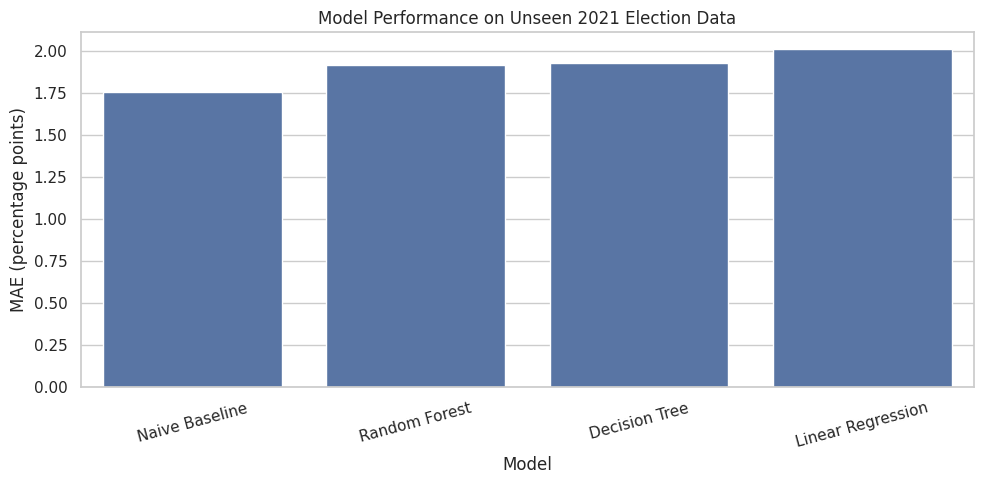

In [ ]:
model_comparison_final = pd.DataFrame({

    "Model": [
        "Naive Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        naive_mae,
        linear_mae,
        dt_mae,
        rf_mae
    ],

    "RMSE": [
        naive_rmse,
        linear_rmse,
        dt_rmse,
        rf_rmse
    ],

    "R2": [
        naive_r2,
        linear_r2,
        dt_r2,
        rf_r2
    ]
})

model_comparison_final = (
    model_comparison_final
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(
    model_comparison_final.style.format({
        "MAE": "{:.3f}",
        "RMSE": "{:.3f}",
        "R2": "{:.3f}"
    })
)

# Graph
plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_comparison_final,
    x="Model",
    y="MAE"
)

plt.title(
    "Model Performance on Unseen 2021 Election Data"
)

plt.xlabel("Model")
plt.ylabel("MAE (percentage points)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## Step 24: Model Evaluation and Selection

Four approaches were evaluated using the unseen 2021 election data: a Naive Baseline, Linear Regression, Decision Tree Regression, and Random Forest Regression.

The results were:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Naive Baseline | 1.757 | 5.210 | 0.861 |
| Random Forest | 1.922 | 5.613 | 0.839 |
| Decision Tree | 1.929 | 5.665 | 0.835 |
| Linear Regression | 2.013 | 5.129 | 0.865 |

The Naive Baseline achieved the lowest MAE of approximately **1.757 percentage points**. This means that, on average, its local vote-share predictions were approximately 1.76 percentage points away from the observed 2021 values.

Linear Regression achieved the lowest RMSE of **5.129** and the highest R² of **0.865**, indicating strong overall explanatory performance. However, its MAE of **2.013** was higher than the Naive Baseline.

Random Forest achieved an MAE of **1.922**, while Decision Tree Regression achieved an MAE of **1.929**. Neither tree-based model improved upon the Naive Baseline on the primary MAE criterion.

MAE is selected as the primary evaluation metric because the target variable is vote share measured in percentage points. It therefore provides a directly interpretable measure of the average prediction error.

Based on the chronological out-of-sample evaluation, the **Naive Baseline is selected as the primary forecasting benchmark** because it achieved the lowest MAE.

The results also demonstrate that increased model complexity does not automatically produce better election forecasts. Historical local voting patterns appear highly persistent, allowing the simple previous-election baseline to perform competitively against the supervised machine-learning models.

**I evaluated the models chronologically on unseen 2021 election data. The naive baseline achieved the lowest MAE of 1.757 percentage points, compared with 1.922 for Random Forest and 1.929 for Decision Tree. Therefore, I selected the model based on observed out-of-sample performance rather than complexity**

## Step 25: Final eThekwini 2026 Election Forecast

The final forecast estimates party-level PR vote shares for the eThekwini Metropolitan Municipality election scheduled for 4 November 2026.

Historical model evaluation showed that the Naive Baseline achieved the lowest Mean Absolute Error (MAE) on the unseen 2021 election data. The baseline assumes that a party's most recently observed electoral support provides the most defensible starting point for the subsequent election when no reliable post-election polling or future election results are available.

Accordingly, the observed 2021 eThekwini PR vote share for each party is carried forward as its baseline estimate for 2026.

These values are **model estimates and not actual 2026 election results**. The forecast does not assume knowledge of events or voting behaviour occurring after the data used in the analysis.

In [ ]:
# ============================================================
# STEP 25.1: FINAL 2026 BASELINE FORECAST
# ============================================================

# Extract actual 2021 party-level PR results
results_2021 = (
    party_year[
        party_year["Year"] == 2021
    ][
        [
            "PartyName",
            "PartyVotes",
            "VoteShare"
        ]
    ]
    .copy()
)

# Naive baseline:
# 2026 estimate = most recent observed 2021 vote share
final_forecast_2026 = results_2021.copy()

final_forecast_2026["ForecastYear"] = 2026

final_forecast_2026[
    "EstimatedVoteShare_2026"
] = final_forecast_2026["VoteShare"]

# Sort largest to smallest
final_forecast_2026 = (
    final_forecast_2026
    .sort_values(
        "EstimatedVoteShare_2026",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 75)
print("FINAL BASELINE FORECAST")
print("eTHEKWINI LOCAL GOVERNMENT ELECTION")
print("4 NOVEMBER 2026")
print("=" * 75)

display(
    final_forecast_2026[
        [
            "PartyName",
            "EstimatedVoteShare_2026"
        ]
    ]
    .head(15)
    .style
    .format({
        "EstimatedVoteShare_2026": "{:.2f}%"
    })
)

print(
    "\nTotal estimated vote share:",
    round(
        final_forecast_2026[
            "EstimatedVoteShare_2026"
        ].sum(),
        2
    ),
    "%"
)

FINAL BASELINE FORECAST
eTHEKWINI LOCAL GOVERNMENT ELECTION
4 NOVEMBER 2026


,PartyName,EstimatedVoteShare_2026
0,AFRICAN NATIONAL CONGRESS,42.51%
1,DEMOCRATIC ALLIANCE,26.33%
2,ECONOMIC FREEDOM FIGHTERS,10.80%
3,INKATHA FREEDOM PARTY,7.45%
4,ACTIONSA,2.35%
5,AFRICAN INDEPENDENT CONGRESS,1.01%
6,ACTIVE CITIZENS COALITION,0.81%
7,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.76%
8,ABANTU BATHO CONGRESS,0.65%
9,JUSTICE AND EMPLOYMENT PARTY,0.61%



Total estimated vote share: 100.0 %


### 25.2 Forecast Uncertainty

Election forecasts should not be presented as exact future outcomes. Historical out-of-sample evaluation of the selected district-level Naive Baseline produced an MAE of approximately **1.757 percentage points**.

This historical MAE is used as a simple empirical uncertainty margin around the 2026 baseline estimates.

The resulting ranges are **descriptive uncertainty bands rather than formal statistical confidence intervals**. Actual 2026 results may fall outside these ranges because future political events, turnout changes, campaigns, party entry or withdrawal, demographic change, and voter behaviour cannot be fully captured by the historical model|

In [ ]:
# ============================================================
# STEP 25.2: ADD EMPIRICAL UNCERTAINTY
# ============================================================

forecast_error_margin = naive_mae

final_forecast_2026["LowerEstimate"] = (
    final_forecast_2026["EstimatedVoteShare_2026"]
    - forecast_error_margin
).clip(lower=0)

final_forecast_2026["UpperEstimate"] = (
    final_forecast_2026["EstimatedVoteShare_2026"]
    + forecast_error_margin
).clip(upper=100)

print("=" * 75)
print("2026 BASELINE FORECAST WITH UNCERTAINTY")
print("=" * 75)

display(
    final_forecast_2026[
        [
            "PartyName",
            "EstimatedVoteShare_2026",
            "LowerEstimate",
            "UpperEstimate"
        ]
    ]
    .head(15)
    .style
    .format({
        "EstimatedVoteShare_2026": "{:.2f}%",
        "LowerEstimate": "{:.2f}%",
        "UpperEstimate": "{:.2f}%"
    })
)

2026 BASELINE FORECAST WITH UNCERTAINTY


,PartyName,EstimatedVoteShare_2026,LowerEstimate,UpperEstimate
0,AFRICAN NATIONAL CONGRESS,42.51%,40.75%,44.26%
1,DEMOCRATIC ALLIANCE,26.33%,24.57%,28.09%
2,ECONOMIC FREEDOM FIGHTERS,10.80%,9.05%,12.56%
3,INKATHA FREEDOM PARTY,7.45%,5.69%,9.21%
4,ACTIONSA,2.35%,0.59%,4.11%
5,AFRICAN INDEPENDENT CONGRESS,1.01%,0.00%,2.77%
6,ACTIVE CITIZENS COALITION,0.81%,0.00%,2.56%
7,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.76%,0.00%,2.52%
8,ABANTU BATHO CONGRESS,0.65%,0.00%,2.40%
9,JUSTICE AND EMPLOYMENT PARTY,0.61%,0.00%,2.37%


### 25.3 Visualisation of the 2026 Baseline Forecast

The following visualisation presents the ten parties with the highest estimated PR vote shares under the selected 2026 baseline model.

The chart represents model estimates rather than observed 2026 election results.

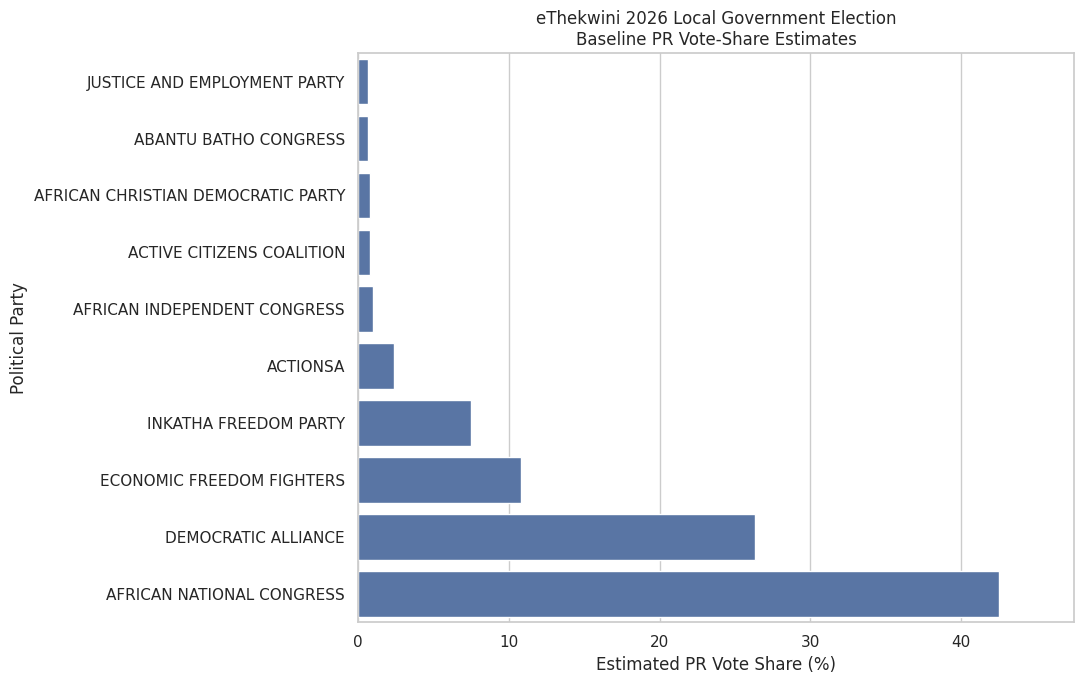

In [ ]:
# ============================================================
# STEP 25.3: FINAL FORECAST VISUALISATION
# ============================================================

top10_forecast = (
    final_forecast_2026
    .head(10)
    .sort_values(
        "EstimatedVoteShare_2026",
        ascending=True
    )
)

plt.figure(figsize=(11, 7))

sns.barplot(
    data=top10_forecast,
    x="EstimatedVoteShare_2026",
    y="PartyName"
)

plt.title(
    "eThekwini 2026 Local Government Election\n"
    "Baseline PR Vote-Share Estimates"
)

plt.xlabel(
    "Estimated PR Vote Share (%)"
)

plt.ylabel(
    "Political Party"
)

plt.xlim(
    0,
    top10_forecast[
        "EstimatedVoteShare_2026"
    ].max() + 5
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# STEP 25.4: MAJORITY THRESHOLD CHECK
# ============================================================

largest_party = final_forecast_2026.iloc[0]

largest_party_name = largest_party["PartyName"]

largest_party_share = largest_party[
    "EstimatedVoteShare_2026"
]

print("=" * 75)
print("MAJORITY THRESHOLD ANALYSIS")
print("=" * 75)

print(
    f"Largest estimated party: "
    f"{largest_party_name}"
)

print(
    f"Estimated PR vote share: "
    f"{largest_party_share:.2f}%"
)

if largest_party_share > 50:

    print(
        "\nThe baseline estimate is above "
        "the 50% PR vote-share threshold."
    )

else:

    print(
        "\nNo party is estimated to exceed "
        "50% of the PR vote under the baseline model."
    )

    print(
        "This does not by itself predict council control "
        "or a specific coalition outcome."
    )

MAJORITY THRESHOLD ANALYSIS
Largest estimated party: AFRICAN NATIONAL CONGRESS
Estimated PR vote share: 42.51%

No party is estimated to exceed 50% of the PR vote under the baseline model.
This does not by itself predict council control or a specific coalition outcome.


## Step 26: Model Diagnostics and Interpretation

Although the Naive Baseline achieved the lowest MAE and was selected for the final 2026 baseline forecast, the supervised machine-learning models can still provide useful information about the historical relationships present in the data.

Random Forest feature importance is examined to identify which historical predictors contributed most strongly to its predictions.

Feature importance does not prove that a variable causes changes in voting behaviour. It only indicates how useful the variable was to the fitted Random Forest model when making predictions.

### 25.5 Interpretation of the Final Forecast

The selected baseline model estimates that the **African National Congress (ANC)** remains the largest party in the eThekwini PR election with approximately **42.51%** of the vote.

The **Democratic Alliance (DA)** follows with approximately **26.33%**, while the **Economic Freedom Fighters (EFF)** and **Inkatha Freedom Party (IFP)** have baseline estimates of approximately **10.80%** and **7.45%**, respectively. **ActionSA** has a baseline estimate of approximately **2.35%**.

Under this baseline scenario, no party exceeds 50% of the estimated PR vote.

These estimates should not be interpreted as known 2026 election outcomes. They represent a conservative data-driven baseline derived from historical IEC election results and the model-selection process.

The chronological evaluation showed that carrying previous-election local vote share forward achieved a lower MAE than the tested Linear Regression, Decision Tree Regression and Random Forest Regression models. Therefore, the simpler baseline was retained rather than selecting a more complex model solely because it uses machine learning.

aThe forecast remains subject to substantial political and electoral uncertainty. Changes in voter turnout, party support, candidate selection, campaigns, political events, party entry or withdrawal and other developments before 4 November 2026 may cause the actual election results to differ materially from these estimates.

In [ ]:
# ============================================================
# STEP 26.1: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Extract fitted preprocessing component
fitted_preprocessor = (
    random_forest_model.named_steps["preprocessor"]
)

# Extract fitted Random Forest
fitted_rf = (
    random_forest_model.named_steps["model"]
)

# Get transformed feature names
feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

# Get feature importance values
importance_values = (
    fitted_rf.feature_importances_
)

# Create table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

display(
    feature_importance
    .head(15)
    .style
    .format({
        "Importance": "{:.4f}"
    })
)

RANDOM FOREST FEATURE IMPORTANCE


,Feature,Importance
0,numeric__PreviousLocalVoteShare,0.9391
1,party__PartyName_MINORITY FRONT,0.0502
2,numeric__RegisteredVoterChange,0.0030
3,party__PartyName_AFRICAN NATIONAL CONGRESS,0.0023
4,numeric__PreviousRegisteredVoters,0.0018
5,numeric__PreviousPartyVotes,0.0017
6,party__PartyName_DEMOCRATIC ALLIANCE,0.0016
7,party__PartyName_INKATHA FREEDOM PARTY,0.0002
8,party__PartyName_AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.0000
9,party__PartyName_TRULY ALLIANCE,0.0000


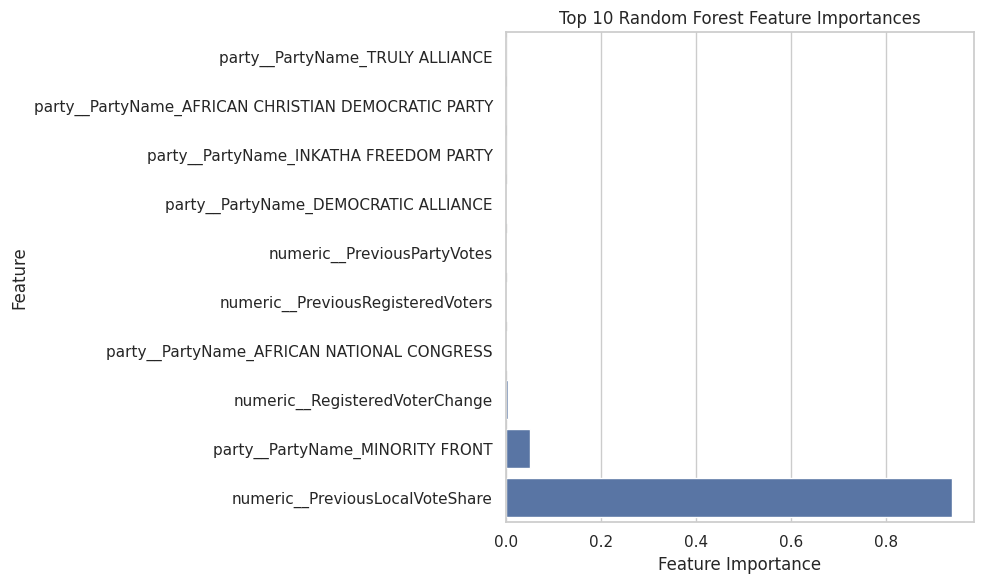

In [ ]:
# STEP 26.2: Plot top Random Forest features

top_features = (
    feature_importance
    .head(10)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Random Forest Feature Importances"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 26.3 Actual Versus Predicted Vote Share

The Random Forest predictions are compared with the actual 2021 local vote shares.

Predictions close to the diagonal reference line indicate relatively accurate predictions, while observations further away from the line represent larger prediction errors.

This diagnostic complements MAE, RMSE and R² by providing a visual assessment of model performance.

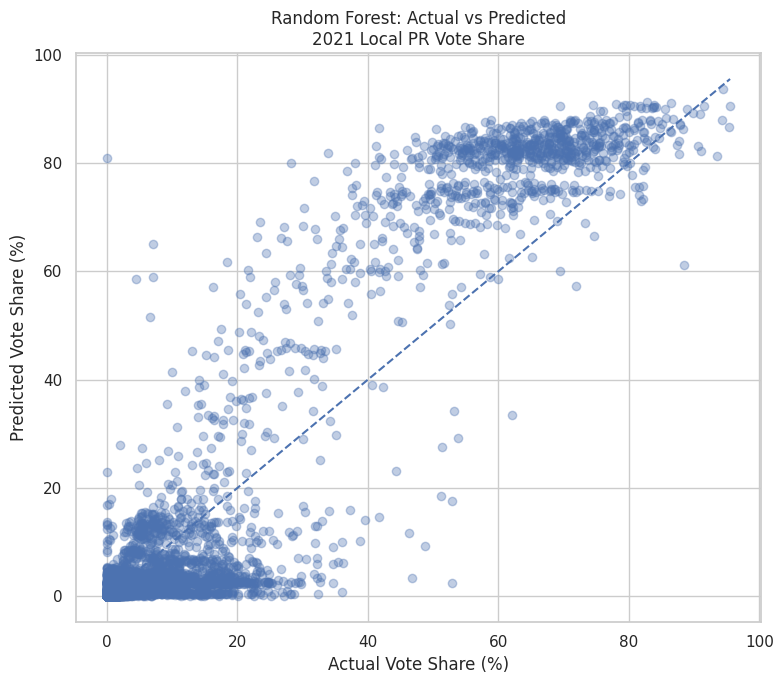

In [ ]:
# STEP 26.3: Actual vs predicted Random Forest vote share

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.35
)

# Perfect prediction reference line
minimum = min(
    y_test.min(),
    rf_predictions.min()
)

maximum = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title(
    "Random Forest: Actual vs Predicted\n"
    "2021 Local PR Vote Share"
)

plt.xlabel(
    "Actual Vote Share (%)"
)

plt.ylabel(
    "Predicted Vote Share (%)"
)

plt.tight_layout()
plt.show()

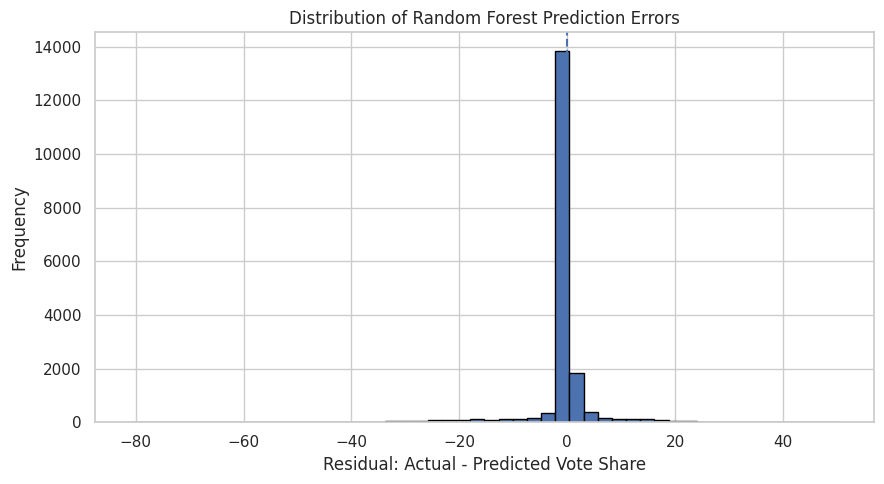

RANDOM FOREST RESIDUAL SUMMARY
Mean residual: -0.418
Median residual: -0.085
Minimum residual: -80.988
Maximum residual: 50.321


In [ ]:
# STEP 26.4: Random Forest residual/error distribution

rf_residuals = (
    y_test.values
    - rf_predictions
)

plt.figure(figsize=(9, 5))

plt.hist(
    rf_residuals,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Distribution of Random Forest Prediction Errors"
)

plt.xlabel(
    "Residual: Actual - Predicted Vote Share"
)

plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

print("=" * 70)
print("RANDOM FOREST RESIDUAL SUMMARY")
print("=" * 70)

print(
    f"Mean residual: {rf_residuals.mean():.3f}"
)

print(
    f"Median residual: {np.median(rf_residuals):.3f}"
)

print(
    f"Minimum residual: {rf_residuals.min():.3f}"
)

print(
    f"Maximum residual: {rf_residuals.max():.3f}"
)

### 26.5 Interpretation of Random Forest Feature Importance

The Random Forest feature-importance analysis shows that **Previous Local Vote Share** is by far the most influential predictor, with an importance score of approximately **0.9391**, representing about 93.91% of the model's total feature importance.

This indicates that historical local party support within a voting district provides substantially more predictive information than the other variables included in the model.

Party identity for the **Minority Front** has the second-highest importance at approximately 0.0502, while Registered Voter Change contributes approximately 0.0030. Previous Registered Voters, Previous Party Votes, and most individual party indicators contribute relatively little to the fitted Random Forest model.

This finding helps explain why the Naive Baseline performed strongly during chronological evaluation. The baseline directly carries the previous local vote share forward, while the Random Forest also relies overwhelmingly on this same historical variable.

Therefore, the feature-importance analysis provides additional evidence that previous local electoral support is the dominant predictive signal in the available historical dataset.

Feature importance should not be interpreted as evidence of causation. The results indicate the variables that were useful to the fitted Random Forest model, not the underlying causes of voter behaviour.

### 26.6 Model Diagnostic Conclusion

The model diagnostics support the final model-selection decision.

Although Linear Regression, Decision Tree Regression and Random Forest Regression were successfully trained and evaluated, none achieved a lower MAE than the Naive Baseline on the unseen 2021 election data.

The Random Forest feature-importance analysis further showed that approximately 93.91% of its feature importance was associated with Previous Local Vote Share. This suggests that much of the useful predictive information captured by the more complex model was already represented by the previous election result.

Consequently, retaining the simpler Naive Baseline is justified by both its superior MAE and the feature-importance evidence.

This result demonstrates the importance of comparing machine-learning models against simple benchmarks rather than assuming that greater model complexity automatically produces more accurate forecasts.

## Step 27: Final Conclusion and Recommendations

### 27.1 Final Conclusion

This project developed a data-driven election analytics and forecasting solution for the eThekwini Metropolitan Municipality using historical South African local government election data from 2011, 2016 and 2021.

The analysis focused on proportional representation (PR) results because PR data provided the most consistent basis for comparison across the three historical elections.

Exploratory data analysis showed substantial changes in party support over time. The African National Congress (ANC) remained the largest party across the historical elections analysed, although its PR vote share declined from approximately 62.02% in 2011 to 59.11% in 2016 and 42.51% in 2021. The Democratic Alliance (DA) increased from approximately 21.81% in 2011 to 27.54% in 2016 before recording approximately 26.33% in 2021. The Economic Freedom Fighters (EFF) recorded approximately 10.80% in 2021, while the Inkatha Freedom Party (IFP) increased to approximately 7.45%.

A supervised machine-learning dataset was subsequently developed using matched party and voting-district observations. The chronological modelling strategy used 8,789 observations from the 2011-to-2016 transition for training and 18,123 observations from the 2016-to-2021 transition for out-of-sample testing.

Linear Regression, Decision Tree Regression and Random Forest Regression were evaluated against a Naive Baseline. The Naive Baseline achieved the lowest Mean Absolute Error (MAE) of approximately 1.757 percentage points. Random Forest achieved an MAE of approximately 1.922, Decision Tree approximately 1.929, and Linear Regression approximately 2.013.

Although Linear Regression achieved a slightly lower RMSE and higher R², the Naive Baseline was retained because MAE was selected as the primary evaluation metric and provides a directly interpretable measure of average vote-share prediction error.

Random Forest feature importance further showed that Previous Local Vote Share accounted for approximately 93.91% of total model feature importance. This supports the conclusion that previous local electoral support contains the dominant predictive signal in the available historical data.

The final 2026 forecast therefore uses the Naive Baseline, carrying the most recently observed 2021 PR vote shares forward as conservative estimates for the 4 November 2026 election.

Under this baseline scenario, the ANC is estimated at approximately 42.51%, followed by the DA at 26.33%, EFF at 10.80%, IFP at 7.45%, and ActionSA at 2.35%.

No party exceeds 50% of the estimated PR vote under the baseline scenario. However, this result alone should not be interpreted as a prediction of council control or a particular coalition outcome.

The 2026 values are model estimates and must not be interpreted as known future election results.

### 27.2 Recommendations

Several improvements could strengthen future versions of the election forecasting system.

Future analysis could incorporate additional credible explanatory variables such as voter registration trends, historical turnout, demographic indicators and other publicly available contextual data where these variables can be reliably matched to the relevant geographical areas.

Additional historical election periods would also improve the ability to identify longer-term electoral trends. The current analysis contains only three municipal election periods, which limits the amount of temporal information available.

The forecasting system should be updated when newer credible information becomes available. However, historical observations, external information and model-generated forecasts should remain clearly distinguished.

Future model development could also investigate whether alternative feature engineering or additional regression algorithms improve performance. Any more complex model should continue to be evaluated against a simple baseline using chronological out-of-sample testing.

Finally, an interactive Streamlit dashboard will be used to communicate historical trends, model performance and the 2026 baseline forecast in an accessible format.

### 27.3 Limitations

The analysis has several important limitations.

Only the 2011, 2016 and 2021 municipal election periods are included. Three election periods provide limited temporal information and restrict the reliability of complex forecasting approaches.

The number and composition of political parties changed between elections. Some parties therefore have much shorter historical records than established parties.

Voting districts also changed between election periods. Although historical identifiers were matched carefully, geographical and administrative changes may affect direct comparability.

The selected Naive Baseline assumes that the most recently observed party support remains unchanged in 2026. It therefore cannot independently anticipate changes caused by political campaigns, leadership changes, new parties, party withdrawals, coalition developments, voter sentiment, turnout changes, demographic change or major political and economic events occurring after the historical data.

The uncertainty bands are based on historical out-of-sample MAE and should be interpreted as descriptive empirical error ranges rather than formal statistical confidence intervals.

Finally, the forecast focuses on PR vote share. It should not be interpreted as a direct forecast of final council seats, ward outcomes, coalition agreements or which political party will ultimately govern eThekwini.

### 27.4 Ethical and Responsible Use

Election forecasting should be communicated carefully because predictions may influence public perceptions of political competition.

The project clearly separates historical election observations from model-generated 2026 estimates. Forecast values are labelled as estimates and are not presented as actual future election results.

The analysis uses aggregated electoral information and does not attempt to identify individual voters or infer the political preferences of specific individuals.

Model limitations and uncertainty are disclosed to avoid presenting the forecast with unjustified precision.

The analysis should therefore be interpreted as a data-driven analytical scenario based on historical electoral patterns rather than a definitive prediction of voter behaviour or the final 2026 election outcome.

### 27.5 Project Summary

The project successfully completed the major stages of a data-science election analytics workflow:

- acquisition and inspection of historical election data;
- data cleaning and standardisation;
- exploratory data analysis and visualisation;
- historical party trend analysis;
- voting-district-level feature engineering;
- chronological training and testing;
- Linear Regression modelling;
- Decision Tree Regression modelling;
- Random Forest Regression modelling;
- comparison against a Naive Baseline;
- model evaluation using MAE, RMSE and R²;
- model interpretation using feature importance;
- selection of the best-performing forecasting benchmark;
- production of a 2026 baseline forecast with uncertainty;
- discussion of limitations and responsible use.

The next stage of the project is to communicate these results through an interactive Streamlit dashboard.

## Step 28: Export Data for the Streamlit Dashboard

The final stage of the notebook prepares the processed analytical outputs for deployment in an interactive Streamlit dashboard.

Separate CSV files are exported for historical party results, the final 2026 baseline forecast, machine-learning model performance, voting-district information, and Random Forest feature importance.

Using processed output files allows the dashboard to focus on presenting and communicating the analytical results without repeating the complete data-cleaning and model-training process every time the application starts.

In [ ]:
# ============================================================
# STEP 28.1: HISTORICAL PARTY RESULTS
# ============================================================

historical_results = party_year[
    [
        "Year",
        "PartyName",
        "PartyVotes",
        "VoteShare"
    ]
].copy()

historical_results = historical_results.sort_values(
    ["Year", "VoteShare"],
    ascending=[True, False]
)

historical_results.to_csv(
    "historical_results.csv",
    index=False
)

print("historical_results.csv created successfully.")
print("Shape:", historical_results.shape)

display(historical_results.head(10))

historical_results.csv created successfully.
Shape: (94, 4)


,Year,PartyName,PartyVotes,VoteShare
0,2011,AFRICAN NATIONAL CONGRESS,603929,62.022351
1,2011,DEMOCRATIC ALLIANCE,212409,21.813997
2,2011,MINORITY FRONT,48064,4.936081
3,2011,NATIONAL FREEDOM PARTY,43606,4.478253
4,2011,INKATHA FREEDOM PARTY,38532,3.957163
5,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6555,0.673186
6,2011,TRULY ALLIANCE,6026,0.618859
7,2011,AFRICAN PEOPLE'S CONVENTION,3970,0.407711
8,2011,CONGRESS OF THE PEOPLE,3882,0.398674
9,2011,UNITED ACTION FRONT,1256,0.128989


In [ ]:
# ============================================================
# STEP 28.2: FINAL 2026 FORECAST
# ============================================================

forecast_export = final_forecast_2026[
    [
        "PartyName",
        "ForecastYear",
        "EstimatedVoteShare_2026",
        "LowerEstimate",
        "UpperEstimate"
    ]
].copy()

forecast_export.to_csv(
    "forecast_2026.csv",
    index=False
)

print("forecast_2026.csv created successfully.")
print("Shape:", forecast_export.shape)

display(forecast_export.head(10))

forecast_2026.csv created successfully.
Shape: (50, 5)


,PartyName,ForecastYear,EstimatedVoteShare_2026,LowerEstimate,UpperEstimate
0,AFRICAN NATIONAL CONGRESS,2026,42.505705,40.748431,44.262979
1,DEMOCRATIC ALLIANCE,2026,26.328969,24.571695,28.086243
2,ECONOMIC FREEDOM FIGHTERS,2026,10.803551,9.046277,12.560825
3,INKATHA FREEDOM PARTY,2026,7.450538,5.693264,9.207812
4,ACTIONSA,2026,2.349316,0.592042,4.106591
5,AFRICAN INDEPENDENT CONGRESS,2026,1.007956,0.000000,2.765230
6,ACTIVE CITIZENS COALITION,2026,0.805307,0.000000,2.562581
7,AFRICAN CHRISTIAN DEMOCRATIC PARTY,2026,0.760646,0.000000,2.517920
8,ABANTU BATHO CONGRESS,2026,0.645123,0.000000,2.402397
9,JUSTICE AND EMPLOYMENT PARTY,2026,0.614790,0.000000,2.372064


In [ ]:
# ============================================================
# STEP 28.3: MODEL PERFORMANCE
# ============================================================

model_performance_export = (
    model_comparison_final.copy()
)

model_performance_export.to_csv(
    "model_performance.csv",
    index=False
)

print("model_performance.csv created successfully.")

display(model_performance_export)

model_performance.csv created successfully.


,Model,MAE,RMSE,R2
0,Naive Baseline,1.757274,5.210429,0.860852
1,Random Forest,1.921759,5.613249,0.838505
2,Decision Tree,1.928968,5.665382,0.835492
3,Linear Regression,2.013176,5.128771,0.865179


In [ ]:
# ============================================================
# STEP 28.4: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance_export = (
    feature_importance.copy()
)

# Clean the sklearn prefixes for dashboard presentation
feature_importance_export["Feature"] = (
    feature_importance_export["Feature"]
    .str.replace(
        "numeric__",
        "",
        regex=False
    )
    .str.replace(
        "party__PartyName_",
        "Party: ",
        regex=False
    )
)

feature_importance_export.to_csv(
    "feature_importance.csv",
    index=False
)

print("feature_importance.csv created successfully.")

display(
    feature_importance_export.head(10)
)

feature_importance.csv created successfully.


,Feature,Importance
0,PreviousLocalVoteShare,0.939064
1,Party: MINORITY FRONT,0.050173
2,RegisteredVoterChange,0.003020
3,Party: AFRICAN NATIONAL CONGRESS,0.002296
4,PreviousRegisteredVoters,0.001842
5,PreviousPartyVotes,0.001733
6,Party: DEMOCRATIC ALLIANCE,0.001641
7,Party: INKATHA FREEDOM PARTY,0.000183
8,Party: AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.000022
9,Party: TRULY ALLIANCE,0.000019


In [ ]:
# ============================================================
# STEP 28.6: PROJECT INFORMATION
# ============================================================

project_info = pd.DataFrame({

    "Item": [
        "Municipality",
        "Historical Elections",
        "Forecast Election Date",
        "Selected Model",
        "Primary Metric",
        "Historical Test MAE",
        "Forecast Type"
    ],

    "Value": [
        "eThekwini Metropolitan Municipality",
        "2011, 2016, 2021",
        "04 November 2026",
        "Naive Baseline",
        "Mean Absolute Error (MAE)",
        f"{naive_mae:.3f} percentage points",
        "PR vote-share baseline estimate"
    ]
})

project_info.to_csv(
    "project_info.csv",
    index=False
)

print("project_info.csv created successfully.")

display(project_info)

project_info.csv created successfully.


,Item,Value
0,Municipality,eThekwini Metropolitan Municipality
1,Historical Elections,"2011, 2016, 2021"
2,Forecast Election Date,04 November 2026
3,Selected Model,Naive Baseline
4,Primary Metric,Mean Absolute Error (MAE)
5,Historical Test MAE,1.757 percentage points
6,Forecast Type,PR vote-share baseline estimate


In [ ]:
# ============================================================
# STEP 28.7: VERIFY STREAMLIT FILES
# ============================================================

import os

dashboard_files = [
    "historical_results.csv",
    "forecast_2026.csv",
    "model_performance.csv",
    "feature_importance.csv",
    "district_results.csv",
    "project_info.csv"
]

print("=" * 70)
print("STREAMLIT DASHBOARD FILE CHECK")
print("=" * 70)

all_files_ready = True

for file in dashboard_files:

    if os.path.exists(file):

        size_kb = (
            os.path.getsize(file) / 1024
        )

        print(
            f"✓ {file:<30} "
            f"{size_kb:,.2f} KB"
        )

    else:

        print(
            f"✗ {file:<30} MISSING"
        )

        all_files_ready = False


print("\n" + "=" * 70)

if all_files_ready:
    print(
        "SUCCESS: All Streamlit dashboard files are ready."
    )
else:
    print(
        "WARNING: One or more files are missing."
    )

print("=" * 70)

STREAMLIT DASHBOARD FILE CHECK
✓ historical_results.csv         5.02 KB
✓ forecast_2026.csv              3.66 KB
✓ model_performance.csv          0.29 KB
✓ feature_importance.csv         0.75 KB
✓ district_results.csv           4,900.85 KB
✓ project_info.csv               0.29 KB

SUCCESS: All Streamlit dashboard files are ready.


### 28.8 Dashboard Deployment Package

The processed dashboard datasets are packaged together for deployment. These files contain the historical results, model evaluation outputs, feature importance information and final 2026 baseline forecast required by the Streamlit application.

In [ ]:
# ============================================================
# STEP 28.8: CREATE STREAMLIT DATA PACKAGE
# ============================================================

import zipfile

zip_filename = (
    "ethekwini_election_dashboard_data.zip"
)

with zipfile.ZipFile(
    zip_filename,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file in dashboard_files:
        zip_file.write(file)


print("=" * 70)
print("STREAMLIT PACKAGE CREATED")
print("=" * 70)

print(zip_filename)

STREAMLIT PACKAGE CREATED
ethekwini_election_dashboard_data.zip


In [ ]:
from google.colab import files

files.download(
    "ethekwini_election_dashboard_data.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 29: Interactive Dashboard Development

An interactive Streamlit dashboard was developed to communicate the results of the eThekwini election analytics project.

The dashboard provides five analytical components:

1. Executive overview of historical and forecast results.
2. Interactive historical party-support analysis.
3. 2026 PR vote-share baseline forecast with uncertainty.
4. Machine-learning model evaluation and feature importance.
5. Voting-district-level exploration.

The dashboard separates observed historical election results from model-generated 2026 estimates to prevent forecasts from being interpreted as known election outcomes.